# 1. import necessay library

In [2]:
# import library
import os
import pandas as pd
import json
import ast
import csv  # Import the standard csv module
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import statistic_tool as stats_t
from typing import List, Dict
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp  # Import K-S test function
import netCDF4 as nc
import geopandas as gpd
from functools import reduce
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cmcrameri import cm  #colormap from crameri
import jenkspy
import matplotlib.colors as mcolors
import statistic_tool as stats_t
from matplotlib.patches import Patch
from matplotlib import colormaps  # Import colormaps
from matplotlib.colors import BoundaryNorm
import re
import traceback
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import copy
from matplotlib.lines import Line2D

# 2. Setup the input and output path

In [ ]:
# workspace path
# Get the current working directory
current_path = os.getcwd()
print("Current Working Directory:", current_path)
# Get the parent directory
parent_path = os.path.dirname(current_path)
# model output path
model_output_fp = os.path.join(parent_path,'Output','Simulation')
print("model_output_fp is",model_output_fp)
# regional path
# region id
region_id = [7]
# Extract the first element from the list
region_id_value = region_id[0]

# Format the region_id
reg_id = f"{region_id_value:02}"  # Uses f-string formatting
# Alternatively, you could use:
# reg_id = str(region_id_value).zfill(2)

print("Region ID:", reg_id)

# regional model output path
model_output_fp_region = os.path.join(model_output_fp,reg_id)

print(model_output_fp_region)

# regional postprocessing output path
postpro_output_fp_region = os.path.join(model_output_fp,'Postprocessing',reg_id)
print(postpro_output_fp_region)
# postprocessing figures
postpro_figure_fp_region = os.path.join(model_output_fp,'figures',reg_id)
print(postpro_figure_fp_region)
# outline shape file path 

shape_region_path_RGI = '/Path/nsidc0770_07.rgi60.Svalbard' # path of the shape file for the region outline, RGI60-07_Svalbard
# path of the glaciers list
rgiid_calibrated_path = os.path.join(model_output_fp,'..','Calibration','Summary')
rgiid_path = os.path.join(rgiid_calibrated_path, '7-calving_cal_ind.csv')
print(rgiid_path)

# shape file of Svalbard

shape_Svalbard_RGI_path = os.path.join(shape_region_path_RGI,"07_rgi60_Svalbard.shp")

# path of AMIS_statis_fp_region
# regional postprocessing output path
AMIS_statis_fp_region = os.path.join(model_output_fp,'..','Calibration','Statistics_model_run',reg_id)

# Define the hillshade TIFF file path
hillshade_tif = os.path.join( model_output_fp,'..','..','RGI60_Info','S0_DTM50_Hillshade.tif')
print('the path of hillshade tif is :',hillshade_tif)

# Define the DTM TIFF file path
DTM_tif = os.path.join( model_output_fp,'..','..','RGI60_Info','NP_S0_DTM50','S0_DTM50.tif')
# Define the RGI60 attributes path
RGI_path = os.path.join(model_output_fp,'..','..','RGI60_Info')

# path of the glaciers list with failed or need to be rerun
rgiid_path_FailRerun_region = os.path.join(model_output_fp,'failed',str(region_id[0]))
print("failrerun rgi list path :",rgiid_path_FailRerun_region)
os.makedirs(rgiid_path_FailRerun_region, exist_ok=True) 

# 3. generate rgiid with attributes list 

In [4]:
# Extract the 'rgiid' column from each DataFrame and convert to proper format
def extract_numeric_ids(df):
    """Extract and format numeric RGI IDs from DataFrame"""
    if df is None or df.empty:
        return set()
    # Convert to string, remove any whitespace, and handle float formatting
    numeric_ids = set()
    for rgiid in df['rgiid']:
        # Convert to string and handle float representation
        rgiid_str = str(rgiid).strip()
        # Remove trailing .0 if present from float conversion
        if rgiid_str.endswith('.0'):
            rgiid_str = rgiid_str[:-2]
        numeric_ids.add(rgiid_str)
    return numeric_ids

def generate_rgiid_attri_df(AMIS_statis_fp_region=None, RGI_path=None, rgiid_path=None, debug_print=False):
    """
    Generate a DataFrame with RGI ID attributes including convergence status,
    tidewater classification, and surge classification for calibrated glaciers.
    
    Parameters:
    AMIS_statis_fp_region (str): Path to AMIS statistics files
    RGI_path (str): Path to RGI data files
    rgiid_path (str): Path to calibrated RGI ID file
    debug_print (bool): Whether to print debug information
    
    Returns:
    pd.DataFrame: DataFrame with RGI ID attributes
    """

    
    # Extract the RGI ID list from the calibrated summary
    rgi_calibrated = pd.read_csv(rgiid_path)
    if debug_print:
        print(f"Calibrated RGI IDs shape: {rgi_calibrated.shape}")
    
    # Create a set of calibrated RGI IDs for fast lookup
    calibrated_rgiids = set(rgi_calibrated['RGIId'].astype(str).str.strip())
    if debug_print:
        print(f"Number of calibrated RGI IDs: {len(calibrated_rgiids)}")
        print(f"Sample calibrated RGI IDs: {sorted(list(calibrated_rgiids))[:5]}")
    
    # Extract RGI IDs from different files - these are DataFrames, not lists!
    rgiid_unconverged_df = stats_t.extract_rgi_ids_robust(filepath=AMIS_statis_fp_region, filename='Bad_AMIS.txt')
    rgiid_converged_df = stats_t.extract_rgi_ids_robust(filepath=AMIS_statis_fp_region, filename='Good_AMIS.txt',max_iterations = 10)
    rgiid_failed_df = stats_t.extract_rgi_ids_robust(filepath=AMIS_statis_fp_region, filename='Failed_glaciers.txt')
     
    rgiid_converged_set = extract_numeric_ids(rgiid_converged_df)
    rgiid_failed_set = extract_numeric_ids(rgiid_failed_df)
    rgiid_unconverged_set = extract_numeric_ids(rgiid_unconverged_df)
    
    if debug_print:
        print(f"Converged RGI IDs count: {len(rgiid_converged_set)}")
        print(f"Sample converged IDs: {sorted(list(rgiid_converged_set))[:5]}")
        print(f"Failed RGI IDs count: {len(rgiid_failed_set)}")
        print(f"Sample failed IDs: {sorted(list(rgiid_failed_set))[:5]}")
        print(f"Unconverged RGI IDs count: {len(rgiid_unconverged_set)}")
        print(f"Sample unconverged IDs: {sorted(list(rgiid_unconverged_set))[:5]}")
    
    # Read tidewater glacier type and surge index from RGI60
    rgi_attri_fn = os.path.join(RGI_path, '07_rgi60_Svalbard.csv')
    rgi_attri = pd.read_csv(rgi_attri_fn, encoding='ISO-8859-1')
    
    if debug_print:
        print(f"RGI Attribute Data shape: {rgi_attri.shape}")
    
    # Prepare lists for DataFrame creation
    rgi_rows = []
    matched_count = 0
    converged_count = 0
    failed_count = 0
    unconverged_count = 0
    
    # Create a mapping from numeric RGI ID to full RGI ID for calibrated glaciers
    calibrated_numeric_to_full = {}
    for rgi_id in calibrated_rgiids:
        # Extract numeric part (remove 'RGI60-' prefix and any leading zeros)
        numeric_id = re.sub(r'^RGI60-', '', str(rgi_id))
        numeric_id = numeric_id.lstrip('0')
        calibrated_numeric_to_full[numeric_id] = rgi_id
    
    if debug_print:
        print(f"Calibrated numeric to full mapping sample: {dict(list(calibrated_numeric_to_full.items())[:5])}")
    
    # Also create reverse mapping for convergence status lookup
    full_to_numeric = {}
    for numeric_id, full_id in calibrated_numeric_to_full.items():
        full_to_numeric[full_id] = numeric_id
    
    # Process each glacier in the RGI attributes
    for index, row in rgi_attri.iterrows():
        rgi_id = str(row['RGIId']).strip()
        
        # Check if this formatted ID is in the calibrated list
        if rgi_id in calibrated_rgiids:
            matched_count += 1
            
            # Get the numeric version from our mapping
            numeric_id = full_to_numeric.get(rgi_id, '')
            
            if debug_print and matched_count <= 3:  # Debug first few matches
                print(f"Processing - Full: {rgi_id}, Numeric: {numeric_id}")
            
            # Determine convergence status
            converged_status = 0  # Default to unconverged
            
            if numeric_id in rgiid_converged_set:
                converged_status = 1  # Mark as converged
                converged_count += 1
            elif numeric_id in rgiid_failed_set:
                converged_status = 2  # Mark as failed
                failed_count += 1
            else:
                unconverged_count += 1
                # Debug unconverged cases
                if debug_print and unconverged_count <= 5:
                    print(f"Unconverged - Full: {rgi_id}, Numeric: {numeric_id}")
            
            # Determine tidewater status
            termty = row['TermType']
            if pd.isna(termty):
                tidewater_status = 0
            else:
                tidewater_status = 1 if termty in [1, 5] else 0
            
            # Determine surge classification
            surgety = row['Surging']
            surge_classification = 0
            
            if not pd.isna(surgety):
                surgety = int(surgety)
                if surgety == 1:
                    surge_classification = 1
                elif surgety == 2:
                    surge_classification = 2
                elif surgety == 3:
                    surge_classification = 3
                elif surgety == 9:
                    surge_classification = 9
            
            # Append the data to the list
            rgi_rows.append({
                'RGIId': rgi_id,
                'RGIId_Numeric': numeric_id,
                'Converged': converged_status,
                'Tidewater': tidewater_status,
                'Surge': surge_classification
            })
    
    if debug_print:
        print(f"\n=== SUMMARY ===")
        print(f"Total matched RGI IDs: {matched_count}")
        print(f"Converged glaciers: {converged_count}")
        print(f"Failed glaciers: {failed_count}")
        print(f"Unconverged glaciers: {unconverged_count}")
        
        # Additional debug: Check intersection between calibrated and converged IDs
        calibrated_numeric_ids = set(calibrated_numeric_to_full.keys())
        common_converged = calibrated_numeric_ids.intersection(rgiid_converged_set)
        common_failed = calibrated_numeric_ids.intersection(rgiid_failed_set)
        
        print(f"\n=== DEBUG: Intersection Analysis ===")
        print(f"Calibrated numeric IDs in converged set: {len(common_converged)}")
        print(f"Calibrated numeric IDs in failed set: {len(common_failed)}")
        print(f"Sample common converged IDs: {sorted(list(common_converged))[:5]}")
        print(f"Sample common failed IDs: {sorted(list(common_failed))[:5]}")
    
    # Create a DataFrame from the list of rows
    rgiid_attri_df = pd.DataFrame(rgi_rows)
    
    if not rgiid_attri_df.empty:
        # Set appropriate data types
        rgiid_attri_df['Converged'] = rgiid_attri_df['Converged'].astype('int8')
        rgiid_attri_df['Tidewater'] = rgiid_attri_df['Tidewater'].astype('int8')
        rgiid_attri_df['Surge'] = rgiid_attri_df['Surge'].astype('int8')
        # save as csv file
        rgiid_attri_df.to_csv(f'{shape_region_path_RGI}/RGI60_07_glacier_attribute_Converge_Tidewater_Surge_info.csv', index=False)
        
        if debug_print:
            print(f"\nFinal DataFrame shape: {rgiid_attri_df.shape}")
            print("Value counts for each attribute:")
            print("Converged:", rgiid_attri_df['Converged'].value_counts().sort_index().to_dict())
            print("Tidewater:", rgiid_attri_df['Tidewater'].value_counts().sort_index().to_dict())
            print("Surge:", rgiid_attri_df['Surge'].value_counts().sort_index().to_dict())
            
            # Show first few rows for verification
            print(f"\nFirst 5 rows:")
            print(rgiid_attri_df.head())
    else:
        if debug_print:
            print("No data found in the final DataFrame!")
    
    return rgiid_attri_df

# Example of how to call the function:
# With debug printing enabled:
# rgiid_attri_df = generate_rgiid_attri_df(AMIS_statis_fp_region, RGI_path, rgiid_path, debug_print=True)

# Without debug printing (silent mode):
# rgiid_attri_df = generate_rgiid_attri_df(AMIS_statis_fp_region, RGI_path, rgiid_path, debug_print=False)




In [ ]:
rgiid_attri_df = generate_rgiid_attri_df(AMIS_statis_fp_region =AMIS_statis_fp_region, RGI_path=RGI_path,rgiid_path=rgiid_path)


# 3.1 generate the glacier list, scenatios, gcm_list

In [7]:
# Senarios list
Senarios =['ssp126','ssp585']

# GCM list
gcm_list = os.listdir(model_output_fp_region)

# Read the rgiid list of glaciers with calibration results (2000-2020)
# Extract the last part of the 'RGIId'
rgi_id_list = rgiid_attri_df['RGIId'].str.split('-', expand=True)[1]  # Get the part after the hyphen
rgi_id_list = rgi_id_list.str.replace('^0+', '', regex=True)  # Optional: remove leading zeros
rgi_id_list = rgi_id_list.tolist()  # Convert to list of strings

# If you specifically want to make sure to keep leading zeros after the decimal
rgi_id_list = [id.lstrip('0') if id.startswith('0') else id for id in rgi_id_list]

# Print result for verification
print(rgi_id_list)

['7.00025', '7.00026', '7.00027', '7.00029', '7.00031', '7.00036', '7.00042', '7.00060', '7.00061', '7.00064', '7.00224', '7.00250', '7.00251', '7.00276', '7.00277', '7.00301', '7.00315', '7.00425', '7.00448', '7.00463', '7.00464', '7.00465', '7.00468', '7.00470', '7.00471', '7.00474', '7.00502', '7.00551', '7.00552', '7.00558', '7.00645', '7.00659', '7.00681', '7.00682', '7.00714', '7.00715', '7.00724', '7.00727', '7.00733', '7.00789', '7.00790', '7.00791', '7.00794', '7.00832', '7.00854', '7.00859', '7.00874', '7.00883', '7.00892', '7.00896', '7.00903', '7.00910', '7.00945', '7.01328', '7.01353', '7.01449', '7.01458', '7.01464', '7.01487', '7.01488', '7.01492', '7.01493', '7.01494', '7.01499', '7.01500', '7.01503', '7.01506', '7.01507', '7.01559', '7.01560', '7.01561']


# 4. Calculate and visulize the sum of a specific field for each glacier over a defined period (2000-2100)

## 4.1 Functions to format rgiid from the RGI60 to short numberic

In [8]:
def format_rgiid_to_long(glacier_id):
    """
    Convert a numeric RGI ID to the standard long format (e.g., RGI60-XX.XXXXXX).
    Args:
        glacier_id: Numeric RGI ID (int or str)
    Returns:
        str: Formatted RGI ID in long format
    """

    # Convert to string and clean
    s = str(glacier_id).replace(',', '.')
    
    # Handle cases with/without decimal point
    if '.' in s:
        parts = s.split('.')
        return f"RGI60-{parts[0].zfill(2)}.{parts[1]}"
    else:
        return f"RGI60-{s[:2]}.{s[2:]}"



# Function to convert the long RGIID to a short one
def format_rgiid_to_short(rgiid):
    """
    Convert a long RGIId to a short one.

    Parameters
    ----------
    rgiid : str
        The long RGIId to convert.

    Returns
    -------
    str
        The short RGIId in the format 'X.YYYYYY'.
    """
    if rgiid.startswith("RGI60-"):
        # Extract the part after "RGI60-"
        parts = rgiid.split('-')[1]  # Get the part after the hyphen
        
        # Split the parts by the decimal
        glacier_id_parts = parts.split('.')

        # Format the short RGIId
        # Convert the first part to an integer to remove leading zeros
        glacier_id_short = f"{int(glacier_id_parts[0])}.{glacier_id_parts[1]}"
        return glacier_id_short  # Return formatted RGIId

    return rgiid  # Return the original RGIId if it doesn't start with "RGI60-"





## 4.2 Functions to calculate the statistic information of each scenario for each glacier

In [9]:
def calculate_stats_per_gcm_glacier(scenario_dict=None, field_name=None, field_background=None, Threshold_nan_ratio=0.5):
    """
    Calculate statistics for each scenario of each glacier in the dictionary.
    
    Args:
        scenario_dict: Dictionary where keys are scenario names and values are DataFrames
                       with glaciers as rows and GCMs as columns.
    
        field_name: Name of the field being analyzed (for physical failure check and logging purposes).
        field_background: Name of the background field (for physical failure check and logging purposes). 
        Threshold_nan_ratio: Ratio threshold to identify glaciers with excessive NaN values (default is 0.5). 
                                if the number of NaN values across all GCMs and scenarios are more than this ratio of total GCMs,
                                it will be flagged, and recorded in the list.   
    Returns:
        Tuple containing: 
            - Dictionary of summary DataFrames for each scenario
            - DataFrame of summary DataFrames for glaciers with all NaN values
            - DataFrame of glaciers with physical failures
            - List of glaciers with the number of NaN values across all GCMs and scenarios are more than a threshold (e.g., 50% of total GCMs)
    """
    scenario_stats = {}
    scenario_stats_nan = {}
    glaciers_nan_exceed_threshold = []  # List to store glaciers with excessive NaN values across all GCMs and scenarios than the threshold
    
    # Calculate total number of GCMs across all scenarios
    total_gcms = 0
    for scenario_name, df in scenario_dict.items():
        if isinstance(df, pd.DataFrame) and not df.empty:
            total_gcms = len(df.columns)
            break  # Assuming same number of GCMs in all scenarios
    
    # Calculate the threshold count
    threshold_count = int(total_gcms * Threshold_nan_ratio)

    for scenario_name, df in scenario_dict.items():
        # Input validation
        if not isinstance(df, pd.DataFrame) or df.empty:
            print(f"Warning: Invalid or empty DataFrame for scenario '{scenario_name}'")
            continue

        # Calculate statistics
        stats_df = pd.DataFrame({
            'Median': df.median(axis=1, skipna=True),
            'IQR25': df.quantile(0.25, axis=1),
            'IQR75': df.quantile(0.75, axis=1),
            'nan_count': df.isna().sum(axis=1),
        })

        # Reset index to get glacier IDs
        stats_df.reset_index(inplace=True)
        stats_df.rename(columns={'index': 'RGIId'}, inplace=True)
        stats_df['Glacier'] = stats_df['RGIId']
        stats_df['RGIId'] = stats_df['RGIId'].apply(format_rgiid_to_long)

        # physical failure check: if the abs of statistic values (values, IQR25,IQR75) > the initial field_background, it indicates physical failure
        physical_failure_mask = (stats_df[['Median', 'IQR25', 'IQR75']].abs() > field_background).any(axis=1)
        stats_df['Physical_Failure'] = physical_failure_mask

        # Identify glaciers with all NaN values
        all_nan_mask = df.isna().all(axis=1)
        
        # Get the glacier IDs that have all NaN values
        nan_glacier_ids = df.index[all_nan_mask]
        nan_glacier_ids = [format_rgiid_to_long(gl_id) for gl_id in nan_glacier_ids]

        # Filter stats_df to get only the glaciers with all NaN values
        stats_nan_df = stats_df[stats_df['RGIId'].isin(nan_glacier_ids)].copy()
        
        # Only set the statistical columns to NA, but keep nan_count meaningful
        # For glaciers with all NaN values, the statistical measures should be NA
        # but nan_count should reflect the actual count (which equals total_models)
        stats_cols = ['Median', 'IQR25', 'IQR75']
        stats_nan_df[stats_cols] = pd.NA
        
        # For these glaciers, nan_count should equal total_models (not be set to NA)
        # This provides useful information about why the stats are NA

        scenario_stats[scenario_name] = stats_df
        scenario_stats_nan[scenario_name] = stats_nan_df

        # Identify glaciers with NaN count exceeding threshold for this scenario
        exceed_threshold_mask = stats_df['nan_count'] > threshold_count
        exceed_threshold_glaciers = stats_df[exceed_threshold_mask]['Glacier'].tolist()
        
        # Add to the global list (avoid duplicates)
        for glacier_id in exceed_threshold_glaciers:
            if glacier_id not in glaciers_nan_exceed_threshold:
                glaciers_nan_exceed_threshold.append(glacier_id)

    # convert scenario_stats_nan to a single DataFrame for easier analysis if needed
    if scenario_stats_nan:
        # List to hold rows
        records = []

        # Loop through the dictionary
        for scenario, df in scenario_stats_nan.items():
            for index, row in df.iterrows():
                records.append({
                    'RGIId': row['RGIId'],
                    'Glacier': format_rgiid_to_short(row['RGIId']) if row['RGIId'] else None,
                    'Scenario': scenario,
                    'GCM': 'All NaN',
                    'Median': row['Median'],
                    'IQR25': row['IQR25'],
                    'IQR75': row['IQR75'],
                    'nan_count': row['nan_count']
                })

        # Create DataFrame from the records
        scenario_stats_nan_df = pd.DataFrame(records)
    else:
        scenario_stats_nan_df = pd.DataFrame(columns=['RGIId', 'Glacier', 'Scenario', 'GCM', 'Median', 'IQR25', 'IQR75', 'nan_count'])

    return scenario_stats, scenario_stats_nan_df, glaciers_nan_exceed_threshold

## 4.3 Functions to joint shape file with dataframe, and join geodataframe with dataframe

In [10]:

def join_stats_to_shape(original_shapefile=None, stats_dict=None, join_column='RGIId'):
    """
    Join statistics from multiple scenarios to a shapefile's attribute table
    and filter to keep only records with values in statistics.
    
    Args:
        original_shapefile: Path to shapefile or GeoDataFrame
        stats_dict: Dictionary of {scenario_name: stats_df} 
                    (output from previous functions)
        join_column: Column name to join on (default 'RGIId')
    
    Returns:
        GeoDataFrame with original geometry + joined statistics, 
        filtered to keep only those with values from stats_dict.
    """
    # Read shapefile if path provided
    if isinstance(original_shapefile, str):
        gdf = gpd.read_file(original_shapefile)
    else:
        gdf = original_shapefile.copy()
    
    # Prepare all DataFrames to merge (starting with original)
    dfs_to_merge = [gdf]
    
    # Process each scenario's statistics
    for scenario_name, stats_df in stats_dict.items():
        # Add scenario suffix to all columns except join column
        stats_df = stats_df.set_index(join_column)
        if not stats_df.empty:
            stats_df.columns = [f"{col}_{scenario_name}" for col in stats_df.columns]
            dfs_to_merge.append(stats_df.reset_index())
    
    # Perform sequential merge
    merged_gdf = reduce(lambda left, right: pd.merge(
        left, 
        right, 
        on=join_column, 
        how='left'
    ), dfs_to_merge)

    # Identify which statistics columns are present in the merged DataFrame
    stats_columns = [f"{col}_{scenario_name}" for scenario_name in stats_dict for col in stats_dict[scenario_name].columns]
    # Filter only those columns that actually exist in merged_gdf
    existing_stats_columns = [col for col in stats_columns if col in merged_gdf.columns]

    # Filter to keep only rows with statistics data (non-null values)
    if existing_stats_columns:  # Check if there are any existing columns
        mask = merged_gdf[existing_stats_columns].notnull().any(axis=1)
        filtered_gdf = merged_gdf[mask]
    else:
        filtered_gdf = merged_gdf  # No stats columns present, keep all

    # Convert back to GeoDataFrame (merge converts to DataFrame)
    return gpd.GeoDataFrame(merged_gdf, geometry='geometry'),gpd.GeoDataFrame(filtered_gdf, geometry='geometry')



In [11]:
def join_geodataframe_with_dataframe(geodf=None, df=None, key='RGIId', how='inner', output_path=None,file_name=None):
    """
    Join a GeoDataFrame with a DataFrame based on a common key and save as a shapefile.
    
    Parameters:
    geodf (gpd.GeoDataFrame): Input GeoDataFrame.
    df (pd.DataFrame): Input DataFrame.
    key (str): The column name to join on (default is 'RGIId').
    how (str): Type of join to perform: 'inner', 'outer', 'left', 'right' (default is 'inner').
    output_path (str, optional): Path where to save the output shapefile.
    file_name (str, optional): Name of the output shapefile (default is 'merged_geodataframe.shp').

    Returns:
    gpd.GeoDataFrame: Joined GeoDataFrame with a reset index.
    """
    
    # Ensure both the GeoDataFrame and DataFrame contain the key
    if key not in geodf.columns:
        raise ValueError(f"Key '{key}' not in GeoDataFrame columns.")
    if key not in df.columns:
        raise ValueError(f"Key '{key}' not in DataFrame columns.")
    
    # Perform the merge operation
    merged = geodf.merge(df, on=key, how=how)
    
    # Reset the index of the merged GeoDataFrame
    merged.reset_index(drop=True, inplace=True)  # drop=True avoids adding the old index as a column
    
    # Save the merged GeoDataFrame as a shapefile if output_path is provided
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        if file_name is None:
            file_name = 'dL_attributes'
        file_path = os.path.join(output_path, file_name + '.shp')
        merged.to_file(file_path)

    return merged



## 4.4 Functions to calculate period sum per glacier per gcm and scenario

In [12]:
def calculate_period_sums_per_Glac_GCM_Senario(rgi_id_list=None, gcm_list=None, Senarios=None, field_name=None, 
                                      model_output_fp_region=None, postpro_output_fp_region=None, Convertfactor=0.001, field_background=None):
    """
    Calculate the sum of a specific field for each glacier over a defined period (2000-2100).

    --Parameters
    rgi_id_list: List of glacier RGI IDs
    gcm_list: List of GCM names
    Senarios: List of climate scenarios
    field_name: Name of the field to analyze
    model_output_fp_region: File path to the model output for the region
    postpro_output_fp_region: File path to the post-processed output for the region
    Convertfactor: Factor to convert the field units (default is 0.001 to convert m to km)
    field_background: string representing the field background name (optional), used for additional filtering if needed.

    --Returns
    A tuple containing:
    - A dictionary of DataFrames, one for each scenario, containing the sum values for each glacier and GCM.
    - A dictionary of DataFrames, one for each scenario, containing the percentage values.
    - A DataFrame containing reference initial values for all glaciers.
    - A DataFrame of records for glaciers that had nan values.
    - A DataFrame of records for glaciers that had all nan values.
    - A DataFrame of physical failure records.
    """

    scenario_dataframes = {} # record the sum values for each glacier and gcm for each scenario
    scenario_dataframes_percent = {} # record the percentage of the sum values compared to the initial value for each glacier and gcm for each scenario
    reference_data = {}  # Dictionary to store initial values for each glacier
    
    allnan_records = []  # List to store all nan value records of glaciers with all nan values for all gcms and scenarios
    hadnan_records = []  # List to store records of glaciers that had any nan values replaced after filtering the physical failure with the background field value
    physical_failure_info = {}  # Dictionary to store physical failure records of the specific glacier, gcm, and scenario and year
    physical_sum_failure_info = {}  # Dictionary to store physical failure records of the specific glacier, gcm, and scenario and year for the sum value calculation
    
    # Dictionary to track NaN counts for each glacier across all GCMs and scenarios
    glacier_nan_tracker = {glacier_id: 0 for glacier_id in rgi_id_list}
    total_combinations = len(gcm_list) * len(Senarios)
    
    # Ensure the model output path exists
    output_fp = os.path.join(postpro_output_fp_region, field_name)
    os.makedirs(output_fp, exist_ok=True)
    
    # File path for missing files
    missing_files_fp = os.path.join(output_fp, f'missing_files_{field_name}.txt')

    # For each scenario
    for scenario in Senarios:
        # Create DataFrames for the current scenario, indexed by glacier ID
        results_df = pd.DataFrame(index=rgi_id_list)
        results_df_percent = pd.DataFrame(index=rgi_id_list)

        # For each GCM
        for gcm in gcm_list:
            gcm_path = os.path.join(model_output_fp_region, gcm)
            scenario_path = os.path.join(gcm_path, scenario, 'stats')

            # Lists to hold sums and percentages for the current GCM
            gcm_sums = []
            gcm_percents = []

            # For each glacier
            for glacier_id in rgi_id_list:
                # Construct the expected filename for this glacier ID
                file = f"{glacier_id}_{gcm}_{scenario}_PBS_ba1_200sets_1981_2100_all.nc"  # Adjust as needed
                file_path = os.path.join(scenario_path, file)

                # Initialize variables
                field_sum = np.nan
                field_percent = np.nan
                had_nan = False
                original_value = None
                physical_sum_failure_detected = False
                initial_value = None
                
                # Check if the file exists before proceeding
                if os.path.exists(file_path):
                    try:
                        # Load the netCDF file
                        dataset = nc.Dataset(file_path)

                        # Extract the desired field if available
                        if field_name in dataset.variables:
                            data = dataset.variables[field_name][:]  # Read the entire data array
                            
                            # exclude the last year 2101 (we want 2000-2100, 100 years)
                            data = data[:, :-1]
                            
                            # Handle different data array types
                            if isinstance(data, np.ma.MaskedArray):
                                # For MaskedArray, convert to regular array with NaN for masked values
                                masked_data = data.filled(np.nan)
                            else:
                                # For regular array, check for fill_value
                                if hasattr(data, 'fill_value'):
                                    fill_value_mask = data == data.fill_value
                                    masked_data = data.copy()
                                    masked_data[fill_value_mask] = np.nan
                                else:
                                    masked_data = data
                            
                            # Get initial value from background field if provided
                            if field_background is not None and field_background in dataset.variables:
                                bg_data = dataset.variables[field_background][:]
                                bg_data = bg_data[:, :-1]  # exclude the last year 2101

                                # Handle background data array types
                                if isinstance(bg_data, np.ma.MaskedArray):
                                    bg_data = bg_data.filled(np.nan)
                                elif hasattr(bg_data, 'fill_value'):
                                    bg_fill_value_mask = (bg_data == bg_data.fill_value)
                                    bg_data = bg_data.copy()
                                    bg_data[bg_fill_value_mask] = np.nan
                                
                                # Get the initial value (first time step)
                                if bg_data.ndim == 2 and bg_data.shape[0] == 1:
                                    initial_value = bg_data[0, 0] * Convertfactor
                                else:
                                    initial_value = bg_data[0] * Convertfactor if bg_data.size > 0 else np.nan
                                
                                # Store initial value for reference (only once per glacier)
                                if glacier_id not in reference_data:
                                    reference_data[glacier_id] = initial_value
                                
                                # Physical failure detection logic
                                filtered_data_abs = np.abs(masked_data)
                                
                                # Check if any value in the field is greater than the background
                                if filtered_data_abs.ndim == 2 and filtered_data_abs.shape[0] == 1:
                                    time_series = filtered_data_abs[0]
                                    bg_series = bg_data[0] if bg_data.ndim == 2 else bg_data
                                    
                                    condition_mask = time_series > bg_series
                                    
                                    if np.any(condition_mask):
                                        failed_time_indices = np.where(condition_mask)[0]
                                        failed_years = [2000 + idx for idx in failed_time_indices]
                                        
                                        original_values = time_series[failed_time_indices].tolist()
                                        background_values = bg_series[failed_time_indices].tolist()
                                        
                                        key = (scenario, gcm, glacier_id)
                                        physical_failure_info[key] = {
                                            'failed_indices': failed_time_indices.tolist(),
                                            'failed_years': failed_years,
                                            'model_values': original_values,
                                            'background_values': background_values
                                        }
                                        
                                        # Set all values to NaN if physical failure detected
                                        masked_data[0, :] = np.nan
                                        
                                else:
                                    # If data shape is unexpected, log and skip
                                    print(f"Unexpected data shape for glacier {glacier_id} in file {file_path}")
                                    masked_data[:] = np.nan

                            # Calculate the sum of the masked data
                            field_sum = np.nanmean(masked_data) * Convertfactor * masked_data.size if not np.all(np.isnan(masked_data)) else np.nan
                            # Double check to make sure the field_sum is valid, if it is negative, then absolute it should be smaller than the initial value,
                            # otherwise it is invalid, and cause the physical failure
#                            if field_sum < 0 and np.abs(field_sum) > np.abs(initial_value):
#                                print("field_sum is :",field_sum)
#                                print("the initial_value is :",initial_value)
#                                field_sum = np.nan
#                                physical_sum_failure_detected = True

                            # Check for NaN values
                            if np.any(np.isnan(masked_data)):
                                had_nan = True
                                original_value = field_sum
                                glacier_nan_tracker[glacier_id] += 1
                                
                            # Calculate percentage if initial value is available and valid
                            if initial_value is not None and not np.isnan(initial_value) and initial_value != 0:
                                field_percent = (field_sum / initial_value) * 100
                            else:
                                field_percent = np.nan
                                
                    except Exception as e:
                        # Handle any errors during file processing
                        error_log_fp = os.path.join(output_fp, f'processing_errors_{field_name}.txt')
                        with open(error_log_fp, 'a') as f:
                            f.write(f"Error processing {file_path}: {str(e)}\n")
                        field_sum = np.nan
                        field_percent = np.nan
                        had_nan = True
                        glacier_nan_tracker[glacier_id] += 1
                else:
                    # Record the missing file
                    with open(missing_files_fp, 'a') as f:
                        f.write(f"The missing file is for_{glacier_id},_with_{gcm},_under_{scenario}\n")
                    field_sum = np.nan
                    field_percent = np.nan
                    had_nan = True
                    glacier_nan_tracker[glacier_id] += 1
                
                # Record had nan value information if found
                if had_nan:
                    hadnan_records.append({
                        'Glacier': glacier_id,
                        'GCM': gcm,
                        'Scenario': scenario,
                        'Original_Value': original_value,
                        'Replaced_With': np.nan,
                    })
                
                # Record physical failure information if detected during sum calculation
                if physical_sum_failure_detected:
                    physical_failure_sum_key = (scenario, gcm, glacier_id)
                    physical_sum_failure_info[physical_failure_sum_key] = {
                        'failed_years': ['All'],  # Indicate all years affected
                        'model_values': [original_value],
                        'background_values': [initial_value],
                        'note': 'Physical failure detected during sum calculation (the retreat larger than the original length); all values set to NaN'
                    }

                # Append the results to the lists
                gcm_sums.append(field_sum)
                gcm_percents.append(field_percent)

            # Add the GCM results as new columns in the DataFrames
            results_df[gcm] = gcm_sums
            results_df_percent[gcm] = gcm_percents

        # Store the DataFrames for the current scenario
        scenario_dataframes[scenario] = results_df
        scenario_dataframes_percent[scenario] = results_df_percent

    # Create reference DataFrame from collected initial values
    reference_df_Final = pd.DataFrame({
        'Glacier': list(reference_data.keys()),
        'Initial_Value': list(reference_data.values())
    })

    # Convert had nan records to DataFrame
    hadnan_df = pd.DataFrame(hadnan_records)

    # Identify glaciers with all NaN values across all GCMs and scenarios
    for glacier_id, nan_count in glacier_nan_tracker.items():
        if nan_count == total_combinations:
            allnan_records.append({
                'Glacier': glacier_id,
                'Total_Combinations': total_combinations,
                'NaN_Count': nan_count,
                'GCM': 'All',
                'Scenario': 'All',
            })
    
    # Convert all nan records to DataFrame
    allnan_df = pd.DataFrame(allnan_records)

    # Save the DataFrames as CSV files
    for scenario, df in scenario_dataframes.items():
        file_fn = f"{field_name}_sums_{scenario}.csv"
        file_path = os.path.join(output_fp, file_fn)
        df.to_csv(file_path)

    for scenario, df in scenario_dataframes_percent.items():
        file_fn = f"{field_name}_sums_{scenario}_percentage.csv"
        file_path = os.path.join(output_fp, file_fn)
        df.to_csv(file_path)

    # Save reference DataFrame
    reference_csv_path = os.path.join(output_fp, f'{field_name}_reference_initial_values.csv')
    reference_df_Final.to_csv(reference_csv_path, index=False)

    # Save had nan values DataFrame if any were found
    if not hadnan_df.empty:
        hadnan_csv_path = os.path.join(output_fp, f'hadnan_glaciers_{field_name}.csv')
        hadnan_df.to_csv(hadnan_csv_path, index=False)

    # Save all nan values DataFrame if any were found
    if not allnan_df.empty:
        allnan_csv_path = os.path.join(output_fp, f'allnan_glaciers_{field_name}.csv')
        allnan_df.to_csv(allnan_csv_path, index=False)
    
    # Convert physical failure info to DataFrame and save if any were found
    physical_failure_rows = []
    for (scenario, gcm, glacier_id), info in physical_failure_info.items():
        for i, year in enumerate(info['failed_years']):
            physical_failure_rows.append({
                'Glacier': glacier_id,
                'GCM': gcm,
                'Scenario': scenario,
                'Year': year,
                'Model_Value': info['model_values'][i],
                'Background_Value': info['background_values'][i],
                'Replaced_With': np.nan,
            })
    
    physical_failure_df = pd.DataFrame(physical_failure_rows)
    if not physical_failure_df.empty:
        physical_failure_csv_path = os.path.join(output_fp, f'{field_name}_physical_failures_info.csv')
        physical_failure_df.to_csv(physical_failure_csv_path, index=False)

    # Convert physical sum failure info to DataFrame and save if any were found
    physical_sum_failure_rows = []
    for (scenario, gcm, glacier_id), info in physical_sum_failure_info.items():
        physical_sum_failure_rows.append({
            'Glacier': glacier_id,
            'GCM': gcm,
            'Scenario': scenario,
            'Year': 'All',
            'Model_Value': info['model_values'][0],
            'Background_Value': info['background_values'][0],
            'Note': info.get('note', ''),
            'Replaced_With': np.nan,
        })
    physical_sum_failure_df = pd.DataFrame(physical_sum_failure_rows)
    if not physical_sum_failure_df.empty:
        physical_sum_failure_csv_path = os.path.join(output_fp, f'{field_name}_physical_sum_failures_info.csv')
        physical_sum_failure_df.to_csv(physical_sum_failure_csv_path, index=False)

    return scenario_dataframes, scenario_dataframes_percent, reference_df_Final, hadnan_df, allnan_df, physical_failure_df, physical_sum_failure_df

## 4.5 Get the statistic information (Median, IQR1,IQR3) of the period sum of length change for each glacier

In [13]:

dL_annual_sum,dL_annual_sum_percent,dL_reference,dL_failed_hadnan_df,dL_failed_allnan_df,dL_peryear_physical_failure_df, dL_sum_physical_failure_df= calculate_period_sums_per_Glac_GCM_Senario(rgi_id_list=rgi_id_list, gcm_list=gcm_list,
                                  Senarios=Senarios,field_name ='glac_length_change_annual',field_background ='glac_length_annual',model_output_fp_region=model_output_fp_region,postpro_output_fp_region=postpro_output_fp_region)


In [14]:
def calculate_stats_per_gcm_glacier(scenario_dict=None, field_name='Initial_Value', background_df=None, 
                                  Threshold_nan_ratio=0.5, threshold_calculation='per_scenario'):
    """
    Calculate statistics for each scenario of each glacier in the dictionary.
    
    Args:
        scenario_dict: Dictionary where keys are scenario names and values are DataFrames
                       with glaciers as rows and GCMs as columns.
        field_name: Name of the field being analyzed (for physical failure check and logging purposes).
        background_df: DataFrame containing the background field values (for physical failure check and logging purposes).
        Threshold_nan_ratio: Ratio threshold to identify glaciers with excessive NaN values (default is 0.5). 
        threshold_calculation: Method for threshold calculation. Options:
                             - 'per_scenario': Calculate threshold separately for each scenario
                             - 'across_scenarios': Calculate threshold across all scenarios combined
                             
    Returns:
        Tuple containing: 
            - Dictionary of summary DataFrames for each scenario
            - DataFrame of summary DataFrames for glaciers with all NaN values
            - List of glaciers with excessive NaN values based on the chosen threshold method
    """
    scenario_stats = {}
    scenario_stats_nan = {}
    glaciers_nan_exceed_threshold = []
    
    # Validate threshold calculation method
    valid_methods = ['per_scenario', 'across_scenarios']
    if threshold_calculation not in valid_methods:
        raise ValueError(f"threshold_calculation must be one of {valid_methods}, got '{threshold_calculation}'")
    
    # Calculate total number of GCMs
    total_gcms = 0
    if scenario_dict:
        for scenario_name, df in scenario_dict.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                total_gcms = len(df.columns)
                break
    
    # Initialize tracking variables
    glacier_nan_counts = {}
    scenario_threshold_info = {}
    
    # First pass: collect nan counts if needed for across_scenarios method
    if threshold_calculation == 'across_scenarios' and scenario_dict:
        # Initialize nan counts for all glaciers
        first_df = next(iter(scenario_dict.values()))
        if isinstance(first_df, pd.DataFrame) and not first_df.empty:
            glacier_nan_counts = {glacier_id: 0 for glacier_id in first_df.index}
        
        # Count total nan across all scenarios
        total_scenarios = len(scenario_dict)
        total_possible_nans = total_gcms * total_scenarios
        
        for scenario_name, df in scenario_dict.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                nan_counts = df.isna().sum(axis=1)
                for glacier_id, count in nan_counts.items():
                    if glacier_id in glacier_nan_counts:
                        glacier_nan_counts[glacier_id] += count

    # Process each scenario
    for scenario_name, df in scenario_dict.items():
        # Input validation
        if not isinstance(df, pd.DataFrame) or df.empty:
            print(f"Warning: Invalid or empty DataFrame for scenario '{scenario_name}'")
            continue

        # Calculate statistics
        stats_df = pd.DataFrame({
            'Median': df.median(axis=1, skipna=True),
            'IQR25': df.quantile(0.25, axis=1),
            'IQR75': df.quantile(0.75, axis=1),
            'nan_count': df.isna().sum(axis=1),
            'total_models': len(df.columns)  # Add total models for reference
        })

        # Reset index to get glacier IDs
        stats_df.reset_index(inplace=True)
        stats_df.rename(columns={'index': 'Glacier'}, inplace=True)
        stats_df['RGIId'] = stats_df['Glacier'].apply(format_rgiid_to_long)
        stats_df['Scenario'] = scenario_name

        # Calculate threshold for this scenario
        scenario_threshold = int(len(df.columns) * Threshold_nan_ratio)
        scenario_threshold_info[scenario_name] = {
            'threshold': scenario_threshold,
            'total_models': len(df.columns)
        }

        # Physical failure check
        if background_df is not None and field_name in background_df.columns:
            if 'Glacier' not in background_df.columns:
                raise ValueError("background_df must contain a 'Glacier' column")
            
            background_mapping = background_df.set_index('Glacier')[field_name]
            stats_df['Background_Value'] = stats_df['Glacier'].map(background_mapping)
            
            stats_abs = stats_df[['Median', 'IQR25', 'IQR75']].abs()
            background_values = stats_df['Background_Value'].abs()
            
            physical_failure_mask = (
                (stats_abs['Median'] > background_values) |
                (stats_abs['IQR25'] > background_values) | 
                (stats_abs['IQR75'] > background_values)
            )
            stats_df['Physical_Failure'] = physical_failure_mask.fillna(False)
        else:
            stats_df['Physical_Failure'] = False
            stats_df['Background_Value'] = np.nan

        # Identify glaciers with all NaN values in this scenario
        all_nan_mask = df.isna().all(axis=1)
        nan_glacier_ids = df.index[all_nan_mask]
        
        stats_nan_df = stats_df[stats_df['Glacier'].isin(nan_glacier_ids)].copy()
        stats_cols = ['Median', 'IQR25', 'IQR75']
        stats_nan_df[stats_cols] = np.nan
        
        scenario_stats[scenario_name] = stats_df
        scenario_stats_nan[scenario_name] = stats_nan_df

        # Identify glaciers that exceed threshold based on chosen method
        if threshold_calculation == 'per_scenario':
            # Per scenario: nan_count > threshold for this specific scenario
            exceed_threshold_mask = stats_df['nan_count'] > scenario_threshold
            exceed_threshold_glaciers = stats_df[exceed_threshold_mask]['Glacier'].tolist()
            
            for glacier_id in exceed_threshold_glaciers:
                glacier_info = {
                    'Glacier': glacier_id,
                    'Scenario': scenario_name,
                    'nan_count': stats_df[stats_df['Glacier'] == glacier_id]['nan_count'].iloc[0],
                    'threshold': scenario_threshold,
                    'total_models': len(df.columns),
                    'method': 'per_scenario'
                }
                if glacier_info not in glaciers_nan_exceed_threshold:
                    glaciers_nan_exceed_threshold.append(glacier_info)

    # Process across_scenarios threshold after all scenarios are processed
    if threshold_calculation == 'across_scenarios' and glacier_nan_counts:
        total_scenarios = len(scenario_dict)
        total_possible_nans = total_gcms * total_scenarios
        across_scenarios_threshold = int(total_possible_nans * Threshold_nan_ratio)
        
        for glacier_id, total_nan_count in glacier_nan_counts.items():
            if total_nan_count > across_scenarios_threshold:
                glacier_info = {
                    'Glacier': glacier_id,
                    'Scenario': 'all_scenarios',
                    'nan_count': total_nan_count,
                    'threshold': across_scenarios_threshold,
                    'total_models': total_possible_nans,
                    'method': 'across_scenarios'
                }
                glaciers_nan_exceed_threshold.append(glacier_info)

    # Convert scenario_stats_nan to a single DataFrame
    records = []
    for scenario, df in scenario_stats_nan.items():
        for index, row in df.iterrows():
            records.append({
                'RGIId': row['RGIId'],
                'Glacier': row['Glacier'],
                'Scenario': scenario,
                'GCM':'All',
                'Median': row['Median'],
                'IQR25': row['IQR25'],
                'IQR75': row['IQR75'],
                'nan_count': row['nan_count'],
                'total_models': row['total_models'],
                'Background_Value': row.get('Background_Value', np.nan),
                'Physical_Failure': row.get('Physical_Failure', False)
            })

    scenario_stats_nan_df = pd.DataFrame(records) if records else pd.DataFrame(columns=[
        'RGIId', 'Glacier', 'Scenario','GCM', 'Median', 'IQR25', 'IQR75', 
        'nan_count', 'total_models', 'Background_Value', 'Physical_Failure'
    ])

    # Convert glaciers_nan_exceed_threshold to DataFrame for better readability
    glaciers_nan_exceed_threshold_df = pd.DataFrame(glaciers_nan_exceed_threshold)
    
    return scenario_stats, scenario_stats_nan_df, glaciers_nan_exceed_threshold_df

In [20]:
dL_sum_stats,dL_sum_stats_nan,dL_sum_stats_nan_exceed_flag =calculate_stats_per_gcm_glacier(scenario_dict=dL_annual_sum,Threshold_nan_ratio=0.5)

In [25]:
dL_sum_percent_stats,dL_sum_percent_stats_nan,dL_sum_percent_stats_nan_exceed_flag =calculate_stats_per_gcm_glacier(scenario_dict=dL_annual_sum_percent,Threshold_nan_ratio=0.5)

# 5  Join the shapefile with dataframe

In [27]:
Join_dL_RGI,Join_dL_RGI_filter = join_stats_to_shape(stats_dict=dL_sum_stats, original_shapefile =shape_Svalbard_RGI_path, join_column='RGIId')

In [28]:
Join_dL_RGI_percent,Join_dL_RGI_percent_filter = join_stats_to_shape(stats_dict=dL_sum_percent_stats, original_shapefile =shape_Svalbard_RGI_path, join_column='RGIId')

## 5.1 join the shape with attribute datafram

In [ ]:
Join_dL_RGI_filter_attr =join_geodataframe_with_dataframe(geodf=Join_dL_RGI_filter, df=rgiid_attri_df, key='RGIId',output_path=shape_region_path_RGI)

In [ ]:
Join_dL_RGI_percent_filter_attr =join_geodataframe_with_dataframe(geodf=Join_dL_RGI_percent_filter, df=rgiid_attri_df, key='RGIId',output_path=shape_region_path_RGI,file_name = 'dL_attributes_Percent')

## 5.3 # attribute_dL_Surge_Converged


In [32]:
field_select = ['RGIId','RGIId_Numeric','Area','Median_ssp126','Median_ssp585','Converged','Surge']
dL_Median_SSP_df = Join_dL_RGI_filter_attr[field_select]
dL_Median_SSP_percent_df = Join_dL_RGI_percent_filter_attr[field_select]

# 6. collect glacier info from failed (all NaN), infinite, and some NaN DataFrames

In [33]:
def collect_fail_nan_rerun_glacierinfo(df_failed=None, df_infinite=None, df_nan=None,
                                       column_name =None, output_path=None, file_name='glacier_simulation_summary_info.txt'):
    """
    Collect the need to rerun glacier info from failed (all NaN), infinite, and nan(some gcm-scenario is nan) df, save the rerun as a csv file,
    and write the whole summary information to a text file (failed, infinite, nan, and rerun).

    Parameters:
    ----------
    df_failed : pd.DataFrame
        DataFrame containing failed glacier information with columns 'RGIId', 'Scenario', and 'GCM'.

    df_infinite : pd.DataFrame
        DataFrame containing infinite glacier information with columns 'RGIId', 'Scenario', and 'GCM'.

    df_nan : pd.DataFrame
        DataFrame containing all NaN glacier information with columns 'RGIId', 'Scenario', and 'GCM'.
    
    column_name : str
        The column name to check for NaN values in df_nan (e.g., 'RGIId', 'Glacier).

    output_path : str
        Path where to save the output text file.
        
    file_name : str
        Name of the output text file (default is 'glacier_info.txt').

    Returns:
    -------
    df_rerun : pd.DataFrame
    DataFrame containing rerun glacier information with columns 'RGIId', 'Scenario', and 'GCM'.

    summary_info: txt file
    a text file containing the summary information of failed, infinite, nan, and rerun glaciers.
    """
    
    # collect the glacier info from the failed dictionary,as a new df

    # df_failed = collect_glacier_scenario_data(dict_failed)

    # Initialize a list to store the collected information
    collected_info = []

    # Helper function to process each DataFrame
    def process_df(df, status):
        if df is not None and not df.empty:
            for index, row in df.iterrows():
                rgiid = row[column_name]
                scenario = row['Scenario']
                gcm = row['GCM']
                collected_info.append(f"{rgiid}, {scenario}, {gcm}, {status}")

    # Process each DataFrame with appropriate status
    process_df(df_failed, "Failed")
    process_df(df_nan, "NaN")
    process_df(df_infinite, "Infinite")

    # collect the  rerun glacier information from the failed, infinite, and nan DataFrames
    # Combine 'Glacier' values from DataFrames df_failed and df_infinite
    glacier_to_remove = set()
    if df_infinite is not None and not df_infinite.empty:
        glacier_to_remove = glacier_to_remove.union(set(df_infinite['Glacier']))
    if df_failed is not None and not df_failed.empty:
        glacier_to_remove = glacier_to_remove.union(set(df_failed['Glacier']))
    # remove the glaciers from the df_nan
    if df_nan is None or df_nan.empty:
        df_rerun = None
    else:
        df_rerun = (df_nan[~df_nan['Glacier'].isin(glacier_to_remove)]).reset_index(drop=True)
    # save the rerun glacier information, if df_rerun is not empty
    if df_rerun is not None and not df_rerun.empty:
        df_rerun.to_csv(os.path.join(output_path, 'Failed_rerun_glacierlist.csv'), index=False)

    # convert the collected_info to a dataframe
    collected_info_df = pd.DataFrame([info.split(', ') for info in collected_info], columns=['Glacier', 'Scenario', 'GCM', 'Status'])
    # Write the collected information df to a csv file if output_path is provided
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        file_path = os.path.join(output_path, file_name+'.csv')  # Ensure the file has a .csv extension
        # save as a csv file
        collected_info_df.to_csv(file_path, index=False)

    return df_rerun, collected_info_df



In [34]:
dL_simu_rerun,dL_simu_errorinfo = collect_fail_nan_rerun_glacierinfo(df_failed= dL_failed_allnan_df, df_infinite= None,
                                                                     df_nan= dL_sum_stats_nan ,column_name = 'Glacier',
                                                                     output_path=rgiid_path_FailRerun_region,
                                                                    file_name='dL_simulation_errinfo')


In [35]:
dL_simu_rerun_percent,dL_simu_errorinfo_percent = collect_fail_nan_rerun_glacierinfo(df_failed= dL_failed_allnan_df, df_infinite= None,
                                                                     df_nan= dL_sum_percent_stats_nan ,column_name = 'Glacier',
                                                                     output_path=rgiid_path_FailRerun_region,
                                                                    file_name='dL_simulation_errinfo')


# 7 Get the Timeseries of Mass change (FA, Mass total, Mass climate)

In [36]:
def record_timeseries_gcm_scenario_postproc(rgi_id_list=None, gcm_list=None, scenarios=None, field_name=None, 
                                 model_output_fp_region=None, postpro_output_fp_region=None,conversion_factor =1,
                                 field_background=None,Failed_info_output_fp=None):
    """
    Calculate the time series values for a specific field for each glacier over a defined period (2000-2100)
    with the postprocessing which will compare the value with the background field (for the frontal ablation, it will
    be the 'glac_mass_annual'), for each glacier with specific gcm and scenario, if any value of the 'glac_frontalablation_annual' is
    > 'glac_mass_annual' at any point in time, then set the value of 'glac_frontalablation_annual' to 'nan' for the glacier of the whole time period,
    i.e. 2000-2100, and also report the physical failure info of the glacier with related 'gcm','scenario', and 'year'.

    Parameters:
    rgi_id_list: List of glacier RGI IDs
    gcm_list: List of GCM names
    scenarios: List of climate scenarios
    field_name: Name of the field to analyze
    model_output_fp_region: File path to the model output for the region
    postpro_output_fp_region: File path to the post-processed output for the region
    conversion_factor : the unit convert factor, default is 1
    field_background: Name of the background field to compare against
    Failed_info_output_fp: File path to output failed information

    Returns:
    A dictionary of DataFrames, each containing time series values for each glacier per (scenario, GCM) with original data.
    A dictionary of DataFrames, each containing time series values for each glacier per (scenario, GCM) with post-processed data.
    A dictionary of physical failure information for each glacier per (scenario, GCM).
    """
    # Correct conversion factor: 1 m³ w.e. = 10⁻⁹ Gt (1 Gt = 10⁹ m³ w.e.) if necessary
    CONVERSION_FACTOR = conversion_factor
    # Initialize dictionaries to hold DataFrames and physical failure information
    scenario_gcm_dataframes = {}
    postprocessed_gcm_dataframes = {}
    physical_failure_info = {}

    # Ensure the model output path exists
    output_fp = os.path.join(postpro_output_fp_region, field_name)
    os.makedirs(output_fp, exist_ok=True)

    # For each scenario
    for scenario in scenarios:
        # For each GCM
        for gcm in gcm_list:
            gcm_path = os.path.join(model_output_fp_region, gcm)
            scenario_path = os.path.join(gcm_path, scenario, 'stats')

            # Create two DataFrames for the current scenario and GCM, indexed by glacier ID, for the original and postprocessing
            results_df = pd.DataFrame(index=rgi_id_list, columns=np.arange(2000, 2101))  # Years from 2000 to 2100
            results_postprocessed_df = pd.DataFrame(index=rgi_id_list, columns=np.arange(2000, 2101))

            # For each glacier
            for glacier_id in rgi_id_list:
                # Construct the expected filename for this glacier ID
                file = f"{glacier_id}_{gcm}_{scenario}_PBS_ba1_200sets_1981_2100_all.nc"  # Adjust as needed
                file_path = os.path.join(scenario_path, file)

                # Initialize the time series for this glacier as NaN
                time_series = np.full(101, np.nan)  # Enough space for 2000-2100 (101 years)

                # Check if the file exists before proceeding
                if os.path.exists(file_path):
                    # Load the netCDF file
                    dataset = nc.Dataset(file_path)

                    # Extract the desired field if available
                    if field_name in dataset.variables:
                        data = dataset.variables[field_name][:]  # Read the entire data array
                        # Exclude the last year (2101)
                        data = data[:, :-1]
                        time_series = data.flatten()*CONVERSION_FACTOR  # Flatten to convert it into 1D array

                        # Create a mask for fill_value
                        fill_value_mask = (time_series == data.fill_value)
                        # Mask the fill_values
                        time_series[fill_value_mask] = np.nan

                        # record the origianl timeseries and post-processed timeseries
                        original_time_series = time_series.copy()
                        # Post-processing: Compare with background field
                        if field_background is not None and field_background in dataset.variables:
                            background_series_data = dataset.variables[field_background][:]
                            background_series = background_series_data.flatten()[:-1]*CONVERSION_FACTOR
                            # Create a mask for fill_value in background series
                            background_fill_value_mask = (background_series == background_series_data.fill_value)
                            background_series[background_fill_value_mask] = np.nan
                            # Convert the filed value to absolute value, to compare with the background value (total mass)
                            Time_series_absolute = np.abs(original_time_series)
                            # If any value in the time series exceeds the background, mask the entire series, and record the nan info
                            if isinstance(background_series, np.ma.MaskedArray):
                                # Check if the MaskedArray is not masked and has any non-masked elements

                                if background_series.count() > 0 and (Time_series_absolute > background_series).any():
                                    
                                    # Create a boolean mask for the condition
                                    condition_mask = Time_series_absolute > background_series
                                    
                                    # Perform the operation using the mask
                                    failed_indices = np.where(condition_mask)[0]  # Get indices of the true condition in numpy array                                    
                                    physical_failure_info[(scenario, gcm, glacier_id)] = {
                                        'failed_indices': failed_indices.tolist(),
                                        'original_values': original_time_series[failed_indices].tolist(),
                                        'background_values': background_series[failed_indices].tolist()
                                    }

                                    # Mask the entire series,if the field_name is "glac_length_change_annual", then just set the condition values to nan, otherwise, set the 
                                    # entire series to nan
                                    if field_name == "glac_length_change_annual":
                                        time_series[condition_mask] = np.nan
                                    else:   
                                        time_series[:] = np.nan
                            else:
                                # For pandas Series
                                if not background_series.empty and (Time_series_absolute > background_series).any():
                                    # record the physical failure info, and the corresponding values in the orginal time series and the background series
                                    physical_failure_info[(scenario, gcm, glacier_id)] = {
                                        'failed_indices': time_series[(Time_series_absolute > background_series)].index.tolist(),
                                        'original_values': original_time_series[(Time_series_absolute > background_series)].tolist(),
                                        'background_values': background_series[(Time_series_absolute > background_series)].tolist()
                                    }
                                    # Mask the entire series,if the field_name is "glac_length_change_annual", then just set the condition values to nan, otherwise, set the 
                                    # entire series to nan
                                    if field_name == "glac_length_change_annual":
                                        time_series[Time_series_absolute > background_series] = np.nan
                                    else:
                                        time_series[:] = np.nan
        
                # Assign the time series to the DataFrame
                results_df.loc[glacier_id] = original_time_series  # Fill in the DataFrame for this glacier
                results_postprocessed_df.loc[glacier_id] = time_series  # Fill in the post-processed DataFrame for this glacier

            # Store the DataFrame for the current scenario and GCM
            scenario_gcm_dataframes[(scenario, gcm)] = results_df
            postprocessed_gcm_dataframes[(scenario, gcm)] = results_postprocessed_df

    # Save the DataFrames as CSV files if needed
    for (scenario, gcm), df in scenario_gcm_dataframes.items():
        file_fn = f"{field_name}_time_series_{scenario}_{gcm}_original.csv"
        file_path = os.path.join(output_fp, file_fn)
        df.to_csv(file_path)

    for (scenario, gcm), df in postprocessed_gcm_dataframes.items():
        file_fn = f"{field_name}_time_series_{scenario}_{gcm}_postprocessed.csv"
        file_path = os.path.join(output_fp, file_fn)
        df.to_csv(file_path)

    # Write the physical failure information to a separate CSV file
        # Prepare data for DataFrame
    rows = []
    for (scenario, gcm, glacier), info in physical_failure_info.items():
        for year in info['failed_indices']:
            rows.append({
                'Glacier': glacier,
                'Scenario': scenario,
                'GCM': gcm,
                'Year': year +2000,  # Convert to a full year,
                'Original_Value': info['original_values'][info['failed_indices'].index(year)],
                'Background_Value': info['background_values'][info['failed_indices'].index(year)]
                })
    # Create a DataFrame
    physical_failure_info_df = pd.DataFrame(rows)
    if Failed_info_output_fp:
        physical_failure_info_file_path = os.path.join(Failed_info_output_fp, f"{field_name}_physically_failed_info.csv")
        physical_failure_info_df.to_csv(physical_failure_info_file_path,index=False)

    return scenario_gcm_dataframes, postprocessed_gcm_dataframes, physical_failure_info_df,physical_failure_info


## 7.1 get the timeseries of FA, Mass total, Mass climate, constrained by the total mass of each year of each glacier

In [37]:
FA_annual_TM,FA_annual_TM_Post,FA_physical_failure,FA_physical_failure_info =record_timeseries_gcm_scenario_postproc(rgi_id_list=rgi_id_list, gcm_list=gcm_list,
                                  scenarios=Senarios, field_name='glac_frontalablation_annual',model_output_fp_region=model_output_fp_region,
                                            postpro_output_fp_region=postpro_output_fp_region,conversion_factor =1e-9,
                                            field_background='glac_mass_annual',Failed_info_output_fp=rgiid_path_FailRerun_region)

In [38]:
MBclim_annual_TM,MBclim_annual_TM_Post,MBclim_physical_failure,MBclim_physical_failure_info =record_timeseries_gcm_scenario_postproc(rgi_id_list=rgi_id_list, gcm_list=gcm_list,
                                  scenarios=Senarios, field_name='glac_massbalclim_annual',model_output_fp_region=model_output_fp_region,
                                            postpro_output_fp_region=postpro_output_fp_region,conversion_factor =1e-9,
                                            field_background='glac_mass_annual',Failed_info_output_fp=rgiid_path_FailRerun_region)

In [39]:
MBtotal_annual_TM,MBtotal_annual_TM_Post,MBtotal_physical_failure,MBtotal_physical_failure_info =record_timeseries_gcm_scenario_postproc(rgi_id_list=rgi_id_list, gcm_list=gcm_list,
                                  scenarios=Senarios, field_name='glac_massbaltotal_annual',model_output_fp_region=model_output_fp_region,
                                            postpro_output_fp_region=postpro_output_fp_region,conversion_factor =1e-9,
                                            field_background='glac_mass_annual',Failed_info_output_fp=rgiid_path_FailRerun_region)

In [40]:
dL_annual_TM,dL_annual_TM_Post,dL_annual_TM_physical_failure,dL_annual_TM_physical_failure_info =record_timeseries_gcm_scenario_postproc(rgi_id_list=rgi_id_list, gcm_list=gcm_list,
                                  scenarios=Senarios, field_name='glac_length_change_annual',model_output_fp_region=model_output_fp_region,
                                            postpro_output_fp_region=postpro_output_fp_region,conversion_factor =1e-3,
                                            field_background='glac_length_annual',Failed_info_output_fp=rgiid_path_FailRerun_region)

## 7.2 Get excluded glacier info for each item , dL, FA, MB_total,MB_clim, and then get Excluded_glacier_total

In [52]:
def identify_excluded_glaciers(dataframes):
    """
    Identify glaciers that should be excluded based on NaN values in their associated data.

    Parameters:
    ----------
    dataframes : dict
        A dictionary where keys are the scenario names (e.g., 'ssp126', 'ssp585'), 
        and values are DataFrames. Each DataFrame should have glaciers as the index 
        and climate models as columns.

    Returns:
    -------
    excluded_glaciers_df : DataFrame
        A DataFrame containing excluded glaciers with columns 'Glacier', 'GCM', 'Scenario'.
    """
    
    # Step 1: Initialize the dictionary to hold excluded glaciers
    global_excluded_glaciers = {}

    # Collect all glaciers that should be excluded
    for scenario, df in dataframes.items():
        # Identify glaciers with NaN values in any year
        for glacier_id in df.index:
            # Check if any value is NaN for that glacier
            if df.loc[glacier_id].isna().any():
                # If glacier_id is not in the dictionary, initialize an entry for it
                if glacier_id not in global_excluded_glaciers:
                    global_excluded_glaciers[glacier_id] = []
                # Append tuples of (scenario, gcm) for glaciers with NaN values
                for gcm in df.columns:  # iterate over each climate model
                    if pd.isna(df.loc[glacier_id][gcm]):  # check if this model has NaN
                        global_excluded_glaciers[glacier_id].append((gcm, scenario))
    
    # Step 2: Convert global_excluded_glaciers to a DataFrame
    excluded_glaciers_data = []
    for glacier_id, exclusions in global_excluded_glaciers.items():
        for gcm, scenario in exclusions:
            excluded_glaciers_data.append((glacier_id, gcm, scenario))

    # Create a DataFrame from the list of tuples
    excluded_glaciers_df = pd.DataFrame(excluded_glaciers_data, columns=['Glacier', 'GCM', 'Scenario'])
    
    return excluded_glaciers_df



In [53]:
FA_exclud_info = identify_excluded_glaciers(FA_annual_TM_Post)
MBclim_exclud_info = identify_excluded_glaciers(MBclim_annual_TM_Post)
MBtotal_exclud_info = identify_excluded_glaciers(MBtotal_annual_TM_Post)
dL_exclud_info = identify_excluded_glaciers(dL_annual_sum)
dL_exclud_info_annual_Post = identify_excluded_glaciers(dL_annual_TM_Post)
dL_exclud_info_annual = identify_excluded_glaciers(dL_annual_TM)

In [61]:
# Get the total excluded glacier list
Total_exclud_info = set(FA_exclud_info['Glacier']).union(set(MBclim_exclud_info['Glacier'])).union(set(MBtotal_exclud_info['Glacier'])).union(set(dL_sum_stats_nan_exceed_flag['Glacier']))

In [62]:
# Get the total excluded glacier list
Total_exclud_info_annual = set(FA_exclud_info['Glacier']).union(set(MBclim_exclud_info['Glacier'])).union(set(MBtotal_exclud_info['Glacier'])).union(set(dL_exclud_info['Glacier'])).union(set(dL_exclud_info_annual['Glacier']))

In [65]:
# Filter the dL_Median_SSP_df
dL_Median_SSP_df_filtered = dL_Median_SSP_df[~dL_Median_SSP_df['RGIId_Numeric'].isin(Total_exclud_info)]
dL_Median_SSP_df_filtered = dL_Median_SSP_df_filtered.sort_values(by='RGIId_Numeric', ascending=True).reset_index(drop=True)
dL_Median_SSP_df_filtered

,RGIId,RGIId_Numeric,Area,Median_ssp126,Median_ssp585,Converged,Surge
0,RGI60-07.00025,7.00025,1095.853,-3.599512,-4.946930,0,3
1,RGI60-07.00026,7.00026,153.538,-4.251538,-7.133358,1,0
2,RGI60-07.00027,7.00027,1226.367,-4.071772,-7.480726,0,2
3,RGI60-07.00029,7.00029,662.905,-6.030095,-8.383435,1,0
4,RGI60-07.00031,7.00031,218.616,-2.574340,-7.996998,1,0
...,...,...,...,...,...,...,...
62,RGI60-07.01503,7.01503,55.385,-0.796244,0.622569,1,2
63,RGI60-07.01507,7.01507,77.165,-0.542596,0.462752,1,0
64,RGI60-07.01559,7.01559,876.603,-5.131897,-6.021915,0,0
65,RGI60-07.01560,7.01560,594.902,-14.207335,-16.696604,1,3


In [66]:
dL_Median_SSP_df_filtered_sorted = dL_Median_SSP_df_filtered.sort_values(by=['Converged','RGIId_Numeric'], ascending=[ False,True]) 
dL_Median_SSP_df_filtered_sorted=dL_Median_SSP_df_filtered_sorted.reset_index(drop=True)
dL_Median_SSP_df_filtered_sorted['Difference'] = dL_Median_SSP_df_filtered_sorted['Median_ssp585'] - dL_Median_SSP_df_filtered_sorted['Median_ssp126']
dL_Median_SSP_df_filtered_sorted

,RGIId,RGIId_Numeric,Area,Median_ssp126,Median_ssp585,Converged,Surge,Difference
0,RGI60-07.00026,7.00026,153.538,-4.251538,-7.133358,1,0,-2.881820
1,RGI60-07.00029,7.00029,662.905,-6.030095,-8.383435,1,0,-2.353341
2,RGI60-07.00031,7.00031,218.616,-2.574340,-7.996998,1,0,-5.422658
3,RGI60-07.00036,7.00036,67.387,-0.679046,-0.592151,1,0,0.086896
4,RGI60-07.00042,7.00042,109.841,-2.014901,1.034052,1,3,3.048953
...,...,...,...,...,...,...,...,...
62,RGI60-07.00859,7.00859,117.553,1.568836,0.850215,0,0,-0.718621
63,RGI60-07.00896,7.00896,34.014,0.440278,1.532802,0,0,1.092524
64,RGI60-07.00945,7.00945,93.023,3.336971,3.274123,0,3,-0.062848
65,RGI60-07.01458,7.01458,163.425,28.312898,24.647460,0,3,-3.665438


In [67]:
# Filter the dL_Median_SSP_df
dL_Median_SSP_percent_df_filtered = dL_Median_SSP_percent_df[~dL_Median_SSP_percent_df['RGIId_Numeric'].isin(Total_exclud_info)]
dL_Median_SSP_percent_df_filtered = dL_Median_SSP_percent_df_filtered.sort_values(by='RGIId_Numeric', ascending=True).reset_index(drop=True)
dL_Median_SSP_percent_df_filtered_sorted = dL_Median_SSP_percent_df_filtered.sort_values(by=['Converged','RGIId_Numeric'], ascending=[ False,True]) 
dL_Median_SSP_percent_df_filtered_sorted=dL_Median_SSP_percent_df_filtered_sorted.reset_index(drop=True)
dL_Median_SSP_percent_df_filtered_sorted['Difference'] = dL_Median_SSP_percent_df_filtered_sorted['Median_ssp585'] - dL_Median_SSP_percent_df_filtered_sorted['Median_ssp126']
dL_Median_SSP_percent_df_filtered_sorted

,RGIId,RGIId_Numeric,Area,Median_ssp126,Median_ssp585,Converged,Surge,Difference
0,RGI60-07.00026,7.00026,153.538,-25.252662,-42.369670,1,0,-17.117008
1,RGI60-07.00029,7.00029,662.905,-17.946711,-24.950700,1,0,-7.003990
2,RGI60-07.00031,7.00031,218.616,-9.751287,-30.291657,1,0,-20.540370
3,RGI60-07.00036,7.00036,67.387,-5.904750,-5.149136,1,0,0.755615
4,RGI60-07.00042,7.00042,109.841,-14.583824,7.484453,1,3,22.068277
...,...,...,...,...,...,...,...,...
62,RGI60-07.00859,7.00859,117.553,7.809815,4.232451,0,0,-3.577364
63,RGI60-07.00896,7.00896,34.014,5.697182,19.834393,0,0,14.137212
64,RGI60-07.00945,7.00945,93.023,19.839302,19.465651,0,3,-0.373651
65,RGI60-07.01458,7.01458,163.425,113.487645,98.795332,0,3,-14.692313


(array([ 1.,  1.,  0.,  2.,  4.,  9., 31., 10.,  6.,  3.]),
 array([-51.10466882, -43.37849843, -35.65232805, -27.92615767,
        -20.19998729, -12.47381691,  -4.74764653,   2.97852386,
         10.70469424,  18.43086462,  26.157035  ]),
 <BarContainer object of 10 artists>)

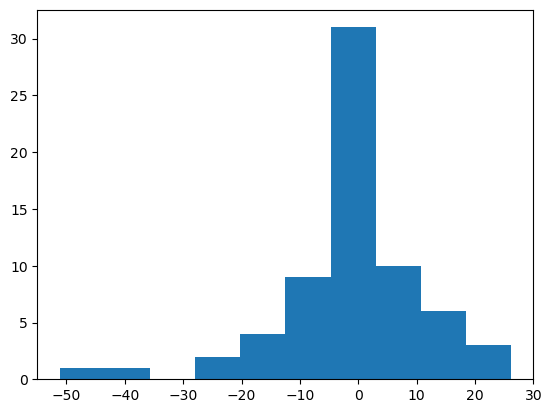

In [126]:
plt.hist(dL_Median_SSP_percent_df_filtered_sorted['Difference'])

(array([ 1.,  4.,  4.,  5.,  7., 30., 12.,  3.,  0.,  1.]),
 array([-7.31729629, -5.94081158, -4.56432687, -3.18784216, -1.81135745,
        -0.43487274,  0.94161197,  2.31809668,  3.69458139,  5.0710661 ,
         6.44755081]),
 <BarContainer object of 10 artists>)

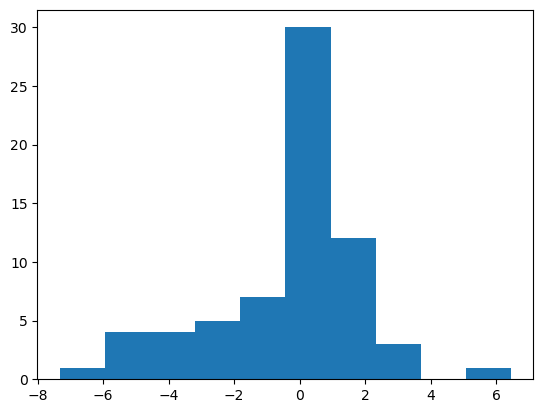

In [130]:
plt.hist(dL_Median_SSP_df_filtered_sorted['Difference'])

In [128]:
np.median(dL_Median_SSP_percent_df_filtered_sorted['Difference'])

-0.11180034383473014

In [131]:
np.median(dL_Median_SSP_df_filtered_sorted['Difference'])

-0.013035920091128972

In [129]:
np.mean(dL_Median_SSP_percent_df_filtered_sorted['Difference'])

-0.8952677454447865

In [132]:
np.mean(dL_Median_SSP_df_filtered_sorted['Difference'])

-0.449830774182968

In [68]:
def plot_median_length_change_per_glacier_scenario(df = None, output_fp=None,figure_size=(12,6),fig_name = None,ylim=None,suffix = None,
                                                  ylabel = 'Total Length Change (km)'):
    """
    Creates a scatter plot of Median_ssp126 vs Median_ssp585.
    
    Parameters:
    - df: DataFrame containing the data with necessary columns.
    - output_fp: File path to save the figure.
    - figure_size: Tuple specifying the size of the figure (default is (12, 6)).
    - fig_name: Name of the figure file to save (default is 'Median_Length_Change.png').
    - ylim: Tuple specifying y-axis limits (default is None, which lets matplotlib decide).

    """
    # Calculate the difference
    df['Difference'] = df['Median_ssp585'] - df['Median_ssp126']

    # Create a scatter plot
    plt.figure(figsize=figure_size)

    # Plot Median_ssp126 values
    plt.scatter(df['RGIId_Numeric'], df['Median_ssp126'], 
                marker='*',
                s=30,  # Size for Median_ssp126
                color=df['Difference'].apply(lambda x: 'red' if x < 0 else 'blue'), 
                alpha=0.6,  # Add transparency
                label='Median_ssp126 (red for negative, blue for positive)')

    # Plot Median_ssp585 values
    plt.scatter(df['RGIId_Numeric'], df['Median_ssp585'], 
                marker='o', 
                s=30,  # Size for Median_ssp585
                color=df['Difference'].apply(lambda x: 'red' if x < 0 else 'blue'),
                alpha=0.6,  # Add transparency
                label='Median_ssp585 (red for negative, blue for positive)')

    # Add dashed line to stress zero difference
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
    # Add dashed line to separate Converged and Unconverged
    # find the index where 'Converged' changes to 'Unconverged', the df is sorted by 'Converged' column descendingly,
    #  we just find the first index where 'Converged' is 0
    if 'Converged' in df.columns:
        unconverged_index = df[df['Converged'] == 0].index[0]
        plt.axvline(x=unconverged_index-0.5, color='black', linestyle='--', linewidth=1)

    # Add asterisks for Surge points at the xaxis, ymin
    ymin, ymax = plt.ylim()
    for index, row in df.iterrows():
        if row['Surge'] > 0:
            plt.text(row['RGIId_Numeric'], ymin, '*', fontsize=12, color='black', ha='center')

    # Add labels and title
    plt.title('Scatter Plot of Median_ssp126 vs Median_ssp585')
    plt.xlabel('Glacier')
    plt.ylabel(ylabel)
    
    # Set x-tick label rotation
    plt.xticks(rotation=90)

    # Add grid
    plt.grid(linestyle='--', alpha=0.5)

    # Show legend
    plt.legend()

    # Save the figure
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
    if output_fp is not None:
        if fig_name is None and suffix is None:
            fig_name = 'Median_Length_Change_SSP.png'
        elif fig_name is None and suffix is not None:
            fig_name = f"Median_Length_Change_SSP_{suffix}.png"
        else:
            fig_name = f"{fig_name}_{suffix}.png"
        output_fp = os.path.join(output_fp, fig_name)
        # save the figure, and set the dipi to 300 for better quality
        plt.savefig(output_fp, dpi=300)  # Saving the figure
        plt.close()  # Close the figure to free memory
    else:
        plt.show()  # Display the figure if no output path is provided
        plt.close()  # Close the figure to free memory

In [69]:
plot_median_length_change_per_glacier_scenario(df = dL_Median_SSP_df_filtered_sorted, output_fp=postpro_figure_fp_region,figure_size=(12,6),fig_name = None,ylim=None)

In [70]:
plot_median_length_change_per_glacier_scenario(df = dL_Median_SSP_percent_df_filtered_sorted, output_fp=postpro_figure_fp_region,figure_size=(12,6),fig_name = None,ylim=None,suffix = 'Percent',
                                                ylabel ='Total Length Change (%)')

# 8. Plot length change map and boxplot

In [78]:
# Function to remove glaciers with NaN based on the key 'naninfo' in global_excluded_glaciers
def remove_nan_glaciers_based_naninfo(GeoDataframe=None, global_excluded_glaciers=None, output_path=None, file_name='dL_attributes'):
    """
    Identify glaciers in the DataFrame based on excluded IDs and remove them. Save the cleaned GeoDataFrame as a shapefile.
    
    Parameters
    ----------
    GeoDataframe : gpd.GeoDataFrame
        A GeoDataFrame with glaciers, including an 'RGIId' attribute.
        
    global_excluded_glaciers : dict
        Dictionary of glacier_id -> list of (scenario, gcm) where it was excluded.

    output_path : str
        Path where to save the output shapefile (without .shp).
        
    file_name : str
        Name for the output shapefile (without extension).

    Returns
    -------
    cleaned_geodf : gpd.GeoDataFrame
        Cleaned GeoDataFrame with excluded glaciers removed.
    global_excluded_glaciers : dict
        Dict of glacier_id -> list of (scenario, gcm) where it was excluded.
    """
    
    # Initialize excluded_ids based on global_excluded_glaciers
    excluded_ids = set()

    if global_excluded_glaciers is not None:
        excluded_ids = global_excluded_glaciers
    
    # Format the RGIId in the excluded_ids as 'RGI60-07.######'
    formatted_excluded_ids = {
        f"RGI60-{int(id.split('.')[0]):02d}.{int(id.split('.')[1]):05d}"
        for id in excluded_ids
    }

    # Step 2: Remove glaciers based on 'RGIId'
    if GeoDataframe is not None:
        # Create mask to filter out excluded glaciers
        mask = ~GeoDataframe['RGIId'].isin(formatted_excluded_ids)
        cleaned_geodf = GeoDataframe[mask].copy()  # Copy to ensure we don't modify the original DataFrame
                # Reset the index of the cleaned GeoDataFrame
        cleaned_geodf.reset_index(drop=True, inplace=True)
        # Save the cleaned GeoDataFrame as a shapefile if output_path is provided
        if output_path:
            os.makedirs(output_path, exist_ok=True)  # Create directory if it doesn't exist
            if file_name is None:
                file_name = 'dL_attributes'
            file_path = os.path.join(output_path, file_name + '_clean.shp')
            cleaned_geodf.to_file(file_path)
    
    return cleaned_geodf


# Function to remove glaciers with NaN values for any scenario/GCM
def remove_nan_glaciers(dataframes = None, extra_excluded_glaciers=None):
    """
    Identify glaciers with NaN in any scenario/GCM and remove them from all DataFrames.

    Parameters
    ----------
    dataframes : dict
        Nested dictionary of DataFrames, keys are tuples (scenario, gcm),
        values are DataFrames with glaciers as index and years as columns.
    extra_excluded_glaciers : list
        List of glacier IDs to exclude in addition to those with NaN values.

    Returns
    -------
    cleaned_dfs : dict
        Same structure as input, but all glaciers with NaN in any DataFrame removed.
    global_excluded_glaciers : dict
        Dict of glacier_id -> list of (scenario, gcm) where it was excluded.
    """


    # Step 1: Identify excluded glaciers globally
    global_excluded_glaciers = {}

    for scenario, df in dataframes.items():
        for glacier_id in df.index:
            if df.loc[glacier_id].isna().any():
                if glacier_id not in global_excluded_glaciers:
                    global_excluded_glaciers[glacier_id] = []
                global_excluded_glaciers[glacier_id].append((scenario))
    if extra_excluded_glaciers is not None:
        exclude_total_list = set(global_excluded_glaciers.keys()).union(set(extra_excluded_glaciers))
    else:
        exclude_total_list = set(global_excluded_glaciers.keys())
    # Step 2: Remove these glaciers from all DataFrames
    cleaned_dfs = copy.deepcopy(dataframes)
    excluded_ids = exclude_total_list
    for key, df in cleaned_dfs.items():
        cleaned_dfs[key] = df.drop(index=excluded_ids)

    return cleaned_dfs, exclude_total_list


# Function to reproject the tif file same as the GeoDataFrame,and maskout the nodata as nan
def reproject_and_mask_tif(tif_path=None, gdf=None,nodata_value=0):
    """
    Reproject a GeoTIFF file to match the CRS and extent of a GeoDataFrame,
    and mask out NoData values as NaN.

    Args:
        tif_path: Path to the input GeoTIFF file.
        gdf: GeoDataFrame to match the CRS and extent.
        nodata_value: Value to treat as NoData (default 0). for Land and ocean areas.

    Returns:
        masked_array: np.ndarray
            The reprojected and masked array.
    """
    # Read the crs from the GeoDataFrame
    gdf_crs = gdf.crs

    # Reproject the tif file to the same crs
    with rasterio.open(tif_path) as src:
        tif_crs = src.crs
        print("Hillshade CRS:", tif_crs)
        Tif = src.read(1)  # Read the first band


    if gdf_crs != tif_crs:
        new_crs = gdf_crs
        # Reproject the Tif to match the GeoDataFrame's CRS
        transform, width, height = calculate_default_transform(
            tif_crs, new_crs, src.width, src.height, *src.bounds)

        # Create a new array to hold the reprojected data
        Tif_reprojected = np.empty((height, width), dtype=np.float32)

        # Perform the reprojection
        reproject(
            Tif,
            Tif_reprojected,
            src_transform=src.transform,
            src_crs=tif_crs,
            dst_transform=transform,
            dst_crs=new_crs,
            resampling=Resampling.bilinear
        )
        reprojected_extent = [transform[2], transform[2] + transform[0] * width, transform[5] + transform[4] * height, transform[5]]
    else:
        Tif_reprojected = Tif
        reprojected_extent = [src.transform[2], src.transform[2] + src.transform[0] * src.width, src.transform[5] + src.transform[4] * src.height, src.transform[5]]
    # Mask out NoData values
    nodata_value = nodata_value  # Adjust this based on what represents NaN in your dataset

    # Create a mask where land is valid
    valid_land_mask =(Tif_reprojected != nodata_value)  # Use bitwise AND for element-wise logical AND

    # Mask the hillshade array to remove ocean areas
    masked_Tif = np.where(valid_land_mask, Tif_reprojected, np.nan)  # Use NaN for ocean values

    return masked_Tif, reprojected_extent


def color_boxplot(ax=None, data_wide=None, scenario_col_name=None, common_order=None, 
                  data_geo=None, custom_cmap=None, norm=None, ylim=None, position_asterisks_at_bottom=False):
    """
    Create a color boxplot for glacier data with line art and glacier colors.
    
    Parameters
    ----------
    ylim : tuple, optional
        The y-axis limits as (ymin, ymax). If provided, ensures consistent asterisk positioning.
    position_asterisks_at_bottom : bool, default=False
        If True, position asterisks at the bottom of the plot (ymin).
        If False, position asterisks at the top of the plot (ymax).
    """
    # Filter out NaN values for each glacier
    boxplot_data = []
    valid_glacier_colors = []
    valid_glacier_ids = []
    
    for glacier_id in common_order:
        glacier_data = data_wide[glacier_id]
        # Remove NaN values
        non_nan_data = glacier_data[~np.isnan(glacier_data)]
        
        if len(non_nan_data) > 0:  # Only include glaciers with valid data
            boxplot_data.append(non_nan_data)
            valid_glacier_ids.append(glacier_id)
            
            # Get color for this glacier
            if '.' in glacier_id:
                parts = glacier_id.split('.')
                parts[0] = parts[0].zfill(2)
                rgi_like_id = 'RGI60-' + '.'.join(parts)
            else:
                rgi_like_id = 'RGI60-' + glacier_id.zfill(2)
                
            match = data_geo[data_geo['RGIId'] == rgi_like_id]
            if not match.empty:
                median_val = match[scenario_col_name].iloc[0]
                valid_glacier_colors.append(custom_cmap(norm(median_val)))
            else:
                valid_glacier_colors.append('gray')

    # Create boxplot only with valid data
    if boxplot_data:
        positions = range(1, len(valid_glacier_ids) + 1)
        boxplot = ax.boxplot(boxplot_data, 
                            positions=positions,
                            labels=valid_glacier_ids, 
                            showfliers=False,
                            showbox=True,
                            showcaps=True,
                            showmeans=False,
                            medianprops={'visible': True, 'color': 'black', 'linewidth': 0.5},
                            whiskerprops={'visible': True, 'color': 'black', 'linewidth': 1},
                            boxprops={'linewidth': 1.5},
                            capprops={'linewidth': 1.5},
                            patch_artist=True)
        
        # Apply colors to all elements of each boxplot
        for i, color in enumerate(valid_glacier_colors):
            # Style the box
            boxplot['boxes'][i].set_facecolor(color)
            boxplot['boxes'][i].set_edgecolor(color)
            
            # Style median line
            boxplot['medians'][i].set_color('black')
            
            # Style whiskers and caps
            boxplot['whiskers'][i*2].set_color(color)
            boxplot['whiskers'][i*2+1].set_color(color)
            boxplot['caps'][i*2].set_color(color)
            boxplot['caps'][i*2+1].set_color(color)
    
    # Add surge type asterisks using data_geo['Surge']
    if 'Surge' in data_geo.columns and boxplot_data:
        # Get the y-axis limits - use provided ylim or current axis limits
        if ylim is not None:
            y_min, y_max = ylim
        else:
            y_min, y_max = ax.get_ylim()
        
        # Determine asterisk position based on parameter
        if position_asterisks_at_bottom == True:
            asterisk_y_position = y_min  # Position at the bottom of the plot
            vertical_alignment = 'top'   # Position above ymin
            
        elif position_asterisks_at_bottom == False:
            asterisk_y_position = y_max  # Position at the top of the plot
            vertical_alignment = 'bottom'  # Position below ymax
        
        # Define surge colors for values 1, 2, 3
        #surge_colors = {1: '#1f77b4', 2: '#2ca02c', 3: '#9467bd'}
        surge_colors = {1: 'black', 2: 'black', 3: 'black'}
        # Add asterisk markers
        if position_asterisks_at_bottom is not None:
            for i, glacier_id in enumerate(valid_glacier_ids):
                # Convert glacier_id to RGI format to match with data_geo
                if '.' in glacier_id:
                    parts = glacier_id.split('.')
                    parts[0] = parts[0].zfill(2)
                    rgi_like_id = 'RGI60-' + '.'.join(parts)
                else:
                    rgi_like_id = 'RGI60-' + glacier_id.zfill(2)
                
                # Find the glacier in data_geo
                match = data_geo[data_geo['RGIId'] == rgi_like_id]
                if not match.empty:
                    surge_value = match['Surge'].iloc[0]
                    if pd.notna(surge_value) and surge_value in surge_colors:
                        # Add simple asterisk (*)
                        ax.text(positions[i], asterisk_y_position, '*', 
                               fontsize=12, fontweight='bold',
                               color=surge_colors[surge_value],
                               ha='center', va=vertical_alignment,
                               clip_on=False, 
                               zorder=10)

    ax.set_ylabel("Total length change (km)", fontsize=12)
    
    # Add dashed gridlines
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    return valid_glacier_ids  # Return the list of valid glacier IDs for synchronization


# Plot the delta L (length change map with the seaborn boxplot)
def plot_ssp_maps_boxplots(data_geo_original=None, data_glacier=None,
                           Geo_Tif=None,
                           grid_shape=(4, 2), figsize=(12, 11),
                           output_path=None, file_name=None, ylim=None,excluded_glaciers=None,breaks_range = (-10,11),step= 1,
                          ylabel = 'Total length change (km)',cbar_label = 'Total length change (km)'):
    """
    Plot SSP126 and SSP585 maps and boxplots with shared colorbar and synchronized axes.

    Parameters
    ----------
    data_geo : GeoDataFrame
        Glacier data with columns 'Median_ssp126' and 'Median_ssp585'.
    data_glacier : GeoDataFrame
        Glacier geometries and attributes for each glacier, has all gcms.
    Geo_Tif : string, the path of the geo tif file
        Hillshade array for background.
    reprojected_extent : list
        Map extent [xmin, xmax, ymin, ymax].
    grid_shape : tuple, default=(4,2)
        GridSpec shape (rows, cols).
    figsize : tuple, default=(12,11)
        Figure size in inches.
    output_path : str or None, default=None
        Path to save the figure. If None, figure is not saved.
    file_name : str or None, default=None
        Name of the file to save. If None, the figure is not saved.
    ylim : tuple or None, default=None
        y-axis limits as (ymin, ymax). If None, defaults are used.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    axes : dict
        Dictionary with keys 'ax1','ax2','ax3','ax4' for the axes.
    """
    # Get the clean Datadict without nan for each glacier
    data_glacier_clean, global_excluded_glaciers = remove_nan_glaciers(dataframes = data_glacier,extra_excluded_glaciers = excluded_glaciers)
    # add the terminus type and surge type, converged info as attributes 
    Join_dL_RGI_filter_attr = join_geodataframe_with_dataframe(geodf=data_geo_original, df=rgiid_attri_df, key='RGIId',output_path= output_path)
    # and Get the clean Geo data based on the global_excluded_glaciers
    Join_dL_RGI_filter_attr_clean = remove_nan_glaciers_based_naninfo(GeoDataframe =Join_dL_RGI_filter_attr,
                                                                 global_excluded_glaciers = global_excluded_glaciers,
                                                                     output_path= output_path)
    # assign the clean value to data_geo
    data_geo = Join_dL_RGI_filter_attr_clean
    # Load the background GeoTiff
    masked_Tif, reprojected_extent = reproject_and_mask_tif(tif_path=Geo_Tif, gdf=data_geo, nodata_value=0)
    
    # ===== Shared color range across both scenarios =====
    min_val = min(
        data_geo['Median_ssp126'].min(),
        data_geo['Median_ssp585'].min()
    )
    max_val = max(
        data_geo['Median_ssp126'].max(),
        data_geo['Median_ssp585'].max()
    )

    # ---- colormap / norm ----
    breaks =  list(range(breaks_range[0], breaks_range[1], step))
    boundaries = [min_val] + breaks + [max_val]
    vik_colors = cm.vik_r(np.linspace(0, 1, len(boundaries)-1))
    custom_cmap = mcolors.ListedColormap(vik_colors)
    norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

    # ===== Figure & GridSpec =====
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = GridSpec(grid_shape[0], grid_shape[1], figure=fig)

    # ===== Maps =====
    axes = {}

    # Define positions as tuples of slices (row_slice, col_slice)
    map_positions = [(slice(0, 2), slice(0, 1)),   # top-left
                     (slice(0, 2), slice(1, 2))]   # top-right
    # labels for the subplots
    labels = ['a', 'b']
    for i, scenario in enumerate(['ssp126', 'ssp585']):
        ax = fig.add_subplot(gs[map_positions[i]], projection=ccrs.PlateCarree())
        
        # Layer 1: Display the masked raster as background (zorder=0)
        ax.imshow(masked_Tif, origin='upper', extent=reprojected_extent,
                  cmap='gray', alpha=0.5, zorder=0)
        
        # Layer 2: Add coastlines (zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
        
        # Layer 3: Plot the median values for the scenario (zorder=2)
        data_geo.plot(
            column=f'Median_{scenario}', ax=ax, legend=False,
            cmap=custom_cmap, norm=norm, edgecolor=None, linewidth=0.5,
            missing_kwds={'color': 'white'},
            zorder=2,
        )
        
        # Layer 4: Plot the hashed areas for non-converged values (zorder=3 - TOP LAYER)
        converged_mask = data_geo['Converged'] == 0
        
        if converged_mask.any():  # Proceed only if there are areas to plot
            unconverged_patch = data_geo[converged_mask].plot(
                ax=ax, 
                facecolor='none',          # No fill color
                edgecolor='black',         # White edge color for hatch
                hatch='/////',              # Diagonal hatch pattern
                alpha=0.7,                 # Slight transparency
                zorder=3,                  # Top layer
                linewidth=0.3,             # Thin edge lines
                label='Unconverged'        # Add label for legend
            )
            
        ax.set_xlim(9, 29)
        ax.set_ylim(76, 81)
        ax.text(0.02, 0.98, scenario.upper(), transform=ax.transAxes,
                ha="left", va="top", fontsize=12, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        # add the labels for the subplot
        ax.annotate(labels[i], xy=(-0.06, 0.95), xycoords='axes fraction',
                    fontsize=18, fontweight='normal',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Set x-ticks and labels
        ax.set_xticks([10, 12.5, 15, 17.5, 20, 22.5, 25,27.5])
        ax.set_xticklabels(['10 E', '12.5 E', '15 E', '17.5 E', '20 E', '22.5 E', '25 E', '27.5 E'], fontsize=10)
        
        # Set y-ticks and labels
        ax.set_yticks([76, 77, 78, 79, 80])
        ax.set_yticklabels(['76 N', '77 N', '78 N', '79 N', '80 N'], fontsize=10)
        
        # Add legend for unconverged areas
        if converged_mask.any():
            ax.legend(handles=[mpatches.Patch(facecolor='none', edgecolor='black', 
                                            hatch='////', alpha=0.5, label='Unconverged')],
                    loc='lower right', fontsize=10, framealpha=0.8)
        
        axes[f'ax{i + 1}'] = ax

    # ===== Boxplots =====
    box126 = data_glacier_clean['ssp126']
    box585 = data_glacier_clean['ssp585']
    if isinstance(box126, pd.Series): box126 = box126.to_frame()
    if isinstance(box585, pd.Series): box585 = box585.to_frame()
    box126 = box126.T
    box585 = box585.T
    
    # Get common glaciers with non-NaN data
    common_order = [g for g in box126.columns if g in box585.columns]
    
    # Separate converged and unconverged glaciers
    converged_glaciers = []
    unconverged_glaciers = []
    
    for glacier_id in common_order:
        if '.' in glacier_id:
            parts = glacier_id.split('.')
            parts[0] = parts[0].zfill(2)
            rgi_like_id = 'RGI60-' + '.'.join(parts)
        else:
            rgi_like_id = 'RGI60-' + glacier_id.zfill(2)
        
        match = data_geo[data_geo['RGIId'] == rgi_like_id]
        if not match.empty:
            if match['Converged'].iloc[0] == 1:
                converged_glaciers.append(glacier_id)
            else:
                unconverged_glaciers.append(glacier_id)
        else:
            # Default to converged if not found
            converged_glaciers.append(glacier_id)
    
    # Create new order: converged first, then unconverged
    new_order = converged_glaciers + unconverged_glaciers
    split_position = len(converged_glaciers)
    print('the number of converged glaciers is :',len(converged_glaciers),'and the number of unconverged glaciers is :',len(unconverged_glaciers))
    
    # Create temporary boxplots to get initial y-limits
    temp_ax3 = fig.add_subplot(gs[grid_shape[0]-2, :])
    valid_glacier_ids_126_temp = color_boxplot(ax=temp_ax3, data_wide=box126, scenario_col_name='Median_ssp126', common_order=new_order,
              data_geo=data_geo, custom_cmap=custom_cmap, norm=norm)
    temp_ax4 = fig.add_subplot(gs[grid_shape[0]-1, :])
    valid_glacier_ids_585_temp = color_boxplot(ax=temp_ax4, data_wide=box585, scenario_col_name='Median_ssp585', common_order=new_order,
              data_geo=data_geo, custom_cmap=custom_cmap, norm=norm)
    
    # Synchronize y-limits between boxplots
    if ylim is not None:
        ymin = ylim[0]
        ymax = ylim[1]
    else:
        ymin = min(temp_ax3.get_ylim()[0], temp_ax4.get_ylim()[0])
        ymax = max(temp_ax3.get_ylim()[1], temp_ax4.get_ylim()[1])
    
    # Remove temporary axes
    temp_ax3.remove()
    temp_ax4.remove()
    
    # ax3: SSP126 boxplot (asterisks at top)
    ax3 = fig.add_subplot(gs[grid_shape[0]-2, :])
    valid_glacier_ids_126 = color_boxplot(ax=ax3, data_wide=box126, scenario_col_name='Median_ssp126', common_order=new_order,
              data_geo=data_geo, custom_cmap=custom_cmap, norm=norm, ylim=(ymin, ymax), position_asterisks_at_bottom=None)

    ax3.text(0.02, 0.95, 'SSP126', transform=ax3.transAxes,
             ha='left', va='top', fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax3.annotate('c', xy=(-0.05, 0.98), xycoords='axes fraction',
                fontsize=18, fontweight='normal',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax3.set_ylabel(ylabel, fontsize=12)
    ax3.tick_params(axis='x', which='both', labelbottom=False)  # Remove x-tick labels for ax3
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_ylim(ymin, ymax)

    # ax4: SSP585 boxplot (asterisks at bottom)
    ax4 = fig.add_subplot(gs[grid_shape[0]-1, :], sharex=ax3)
    valid_glacier_ids_585 = color_boxplot(ax=ax4, data_wide=box585, scenario_col_name='Median_ssp585', common_order=new_order,
              data_geo=data_geo, custom_cmap=custom_cmap, norm=norm, ylim=(ymin, ymax), position_asterisks_at_bottom=True)

    # Ensure both boxplots use the same glacier order
    common_valid_glaciers = list(set(valid_glacier_ids_126) & set(valid_glacier_ids_585))
    common_valid_glaciers.sort(key=lambda x: new_order.index(x))
    
    # Add split line (same as ax3)
    if split_position > 0 and split_position < len(common_valid_glaciers):
        ax4.axvline(x=split_position + 0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)

    ax4.text(0.02, 0.95, 'SSP585', transform=ax4.transAxes,
             ha='left', va='top', fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax4.annotate('d', xy=(-0.05, 0.98), xycoords='axes fraction',
                fontsize=18, fontweight='normal',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax4.set_xlabel("Glaciers", fontsize=12)
    ax4.set_ylabel(ylabel, fontsize=12)
    for label in ax4.get_xticklabels():
        label.set_rotation(90)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_ylim(ymin, ymax)

    # NOW add split line and labels after y-limits are synchronized
    if split_position > 0 and split_position < len(common_valid_glaciers):
        ax3.axvline(x=split_position + 0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax4.axvline(x=split_position + 0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)
        
        # Add labels for converged and unconverged sections (transparent)
        mid_converged = split_position / 2 + 0.5
        mid_unconverged = split_position + (len([g for g in common_valid_glaciers if g in unconverged_glaciers]) / 2) + 0.5
        
        # Use the synchronized ymax for consistent positioning
        y_top = ymax * 0.95
        
        # Make text transparent (alpha=0 for background)
        ax3.text(mid_converged, y_top, 'Converged', 
                ha='center', va='top', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))  # alpha=0 for transparency
        
        if any(g in unconverged_glaciers for g in common_valid_glaciers):
            ax3.text(mid_unconverged-0.85, y_top, 'Unconverged', 
                    ha='center', va='top', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))  # alpha=0 for transparency
    
    axes['ax3'] = ax3
    axes['ax4'] = ax4

    # ===== Shared colorbar =====
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    
    # Get figure coordinates
    fig_left, fig_bottom = 0.0, 0.0
    fig_width, fig_height = 1.0, 1.0  # normalized figure coordinates
    
    # Define colorbar size
    cbar_width = 0.02       # 2% of figure width
    cbar_height = 0.5       # 50% of figure height
    cbar_left = 1.01        # slightly outside the figure's right edge
    cbar_bottom = (fig_height - cbar_height) / 2  # vertically center
    
    # Add axes for the colorbar
    cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label(cbar_label, fontsize=12)
    cbar.set_ticks(boundaries)
    cbar.set_ticklabels([f"{min_val:.1f}"] + [str(b) for b in breaks] + [f"{max_val:.1f}"])
    cbar.ax.tick_params(labelsize=7)
  
    # Save if requested
    if output_path is not None:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        if file_name is not None:
            file_path = os.path.join(output_path, file_name + '.png')
        else:
            file_path = os.path.join(output_path, 'Total_dL_20002100_Geomap_Updated.png')
        fig.savefig(file_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return global_excluded_glaciers, Join_dL_RGI_filter_attr_clean

In [ ]:
data_geo_original=Join_dL_RGI_filter
data_glacier=dL_annual_sum
Geo_Tif= hillshade_tif
excluded_glaciers= Total_exclud_info
output_path = postpro_figure_fp_region
# Get the clean Datadict without nan for each glacier
data_glacier_clean, global_excluded_glaciers = remove_nan_glaciers(dataframes = data_glacier,extra_excluded_glaciers = excluded_glaciers)
# add the terminus type and surge type, converged info as attributes 
Join_dL_RGI_filter_attr = join_geodataframe_with_dataframe(geodf=data_geo_original, df=rgiid_attri_df, key='RGIId',output_path= output_path)
# and Get the clean Geo data based on the global_excluded_glaciers
Join_dL_RGI_filter_attr_clean = remove_nan_glaciers_based_naninfo(GeoDataframe =Join_dL_RGI_filter_attr,
                                                             global_excluded_glaciers = global_excluded_glaciers,
                                                                 output_path= output_path)
# assign the clean value to data_geo
data_geo = Join_dL_RGI_filter_attr_clean

/tmp/ipykernel_839257/4166155151.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(file_path)
/home/ruitang/miniconda3/envs/oggm_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Glacier_ssp126' to 'Glacier_ss'
  ogr_write(
/home/ruitang/miniconda3/envs/oggm_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Median_ssp126' to 'Median_ssp'
  ogr_write(
/home/ruitang/miniconda3/envs/oggm_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'IQR25_ssp126' to 'IQR25_ssp1'
  ogr_write(
/home/ruitang/miniconda3/envs/oggm_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'IQR75_ssp126' to 'IQR75_ssp1'
  ogr_write(
/home/ruitang/miniconda3/envs/oggm_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: N

Hillshade CRS: EPSG:25833
the number of converged glaciers is : 59 and the number of unconverged glaciers is : 8


/tmp/ipykernel_839257/2975444876.py:207: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(boxplot_data,
/tmp/ipykernel_839257/2975444876.py:207: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(boxplot_data,
/tmp/ipykernel_839257/2975444876.py:207: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(boxplot_data,
/tmp/ipykernel_839257/2975444876.py:207: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(boxplot_data,


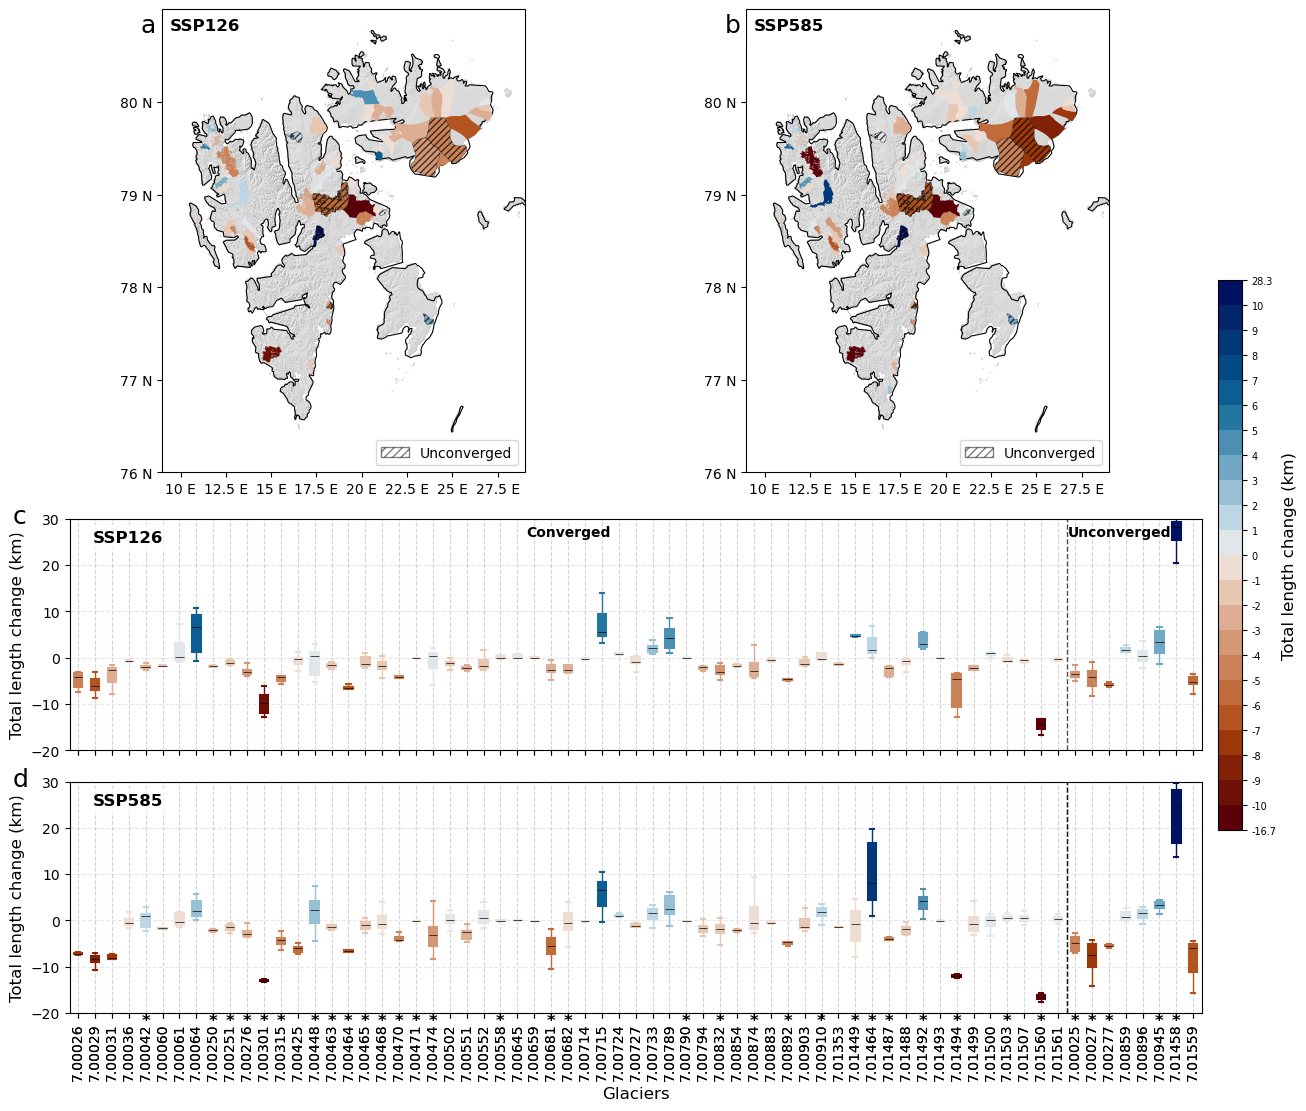

In [84]:
global_excluded_glaciers_DL_Nan,Join_dL_RGI_filter_attr_clean = plot_ssp_maps_boxplots(data_geo_original=Join_dL_RGI_filter, data_glacier=dL_annual_sum,
                           Geo_Tif= hillshade_tif, grid_shape=(4, 2), figsize=(12, 11),
                           output_path=postpro_figure_fp_region, file_name=None,excluded_glaciers= Total_exclud_info,ylim =(-20,30))

In [85]:
global_excluded_glaciers_DL_Nan

{'7.00224', '7.00791', '7.01328', '7.01506'}

In [86]:
Join_dL_RGI_filter

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Background_Value_ssp126,Glacier_ssp585,Median_ssp585,IQR25_ssp585,IQR75_ssp585,nan_count_ssp585,total_models_ssp585,Scenario_ssp585,Physical_Failure_ssp585,Background_Value_ssp585
24,RGI60-07.00025,G023512E79401N,20010710,-9999999,23.5121,79.4014,7,1,1095.853,11,...,NaN,7.00025,-4.946930,-6.510547,-3.608568,0.0,12.0,ssp585,False,NaN
25,RGI60-07.00026,G024447E79366N,20010710,-9999999,24.4470,79.3657,7,1,153.538,28,...,NaN,7.00026,-7.133358,-7.282455,-6.951972,0.0,12.0,ssp585,False,NaN
26,RGI60-07.00027,G024554E79593N,20010710,-9999999,24.5544,79.5931,7,1,1226.367,2,...,NaN,7.00027,-7.480726,-9.952465,-5.074887,0.0,12.0,ssp585,False,NaN
28,RGI60-07.00029,G025601E79742N,20010710,-9999999,25.6010,79.7418,7,1,662.905,10,...,NaN,7.00029,-8.383435,-9.072867,-7.722692,0.0,12.0,ssp585,False,NaN
30,RGI60-07.00031,G026607E79872N,20010710,-9999999,26.6074,79.8722,7,1,218.616,20,...,NaN,7.00031,-7.996998,-8.241103,-7.516370,0.0,12.0,ssp585,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,RGI60-07.01506,G018474E78680N,20080901,-9999999,18.4735,78.6798,7,1,963.857,52,...,NaN,7.01506,NaN,NaN,NaN,12.0,12.0,ssp585,False,NaN
1506,RGI60-07.01507,G020858E78829N,20080901,-9999999,20.8581,78.8292,7,1,77.165,20,...,NaN,7.01507,0.462752,-0.065778,0.968595,0.0,12.0,ssp585,False,NaN
1558,RGI60-07.01559,G018349E78926N,20020713,-9999999,18.3490,78.9255,7,1,876.603,32,...,NaN,7.01559,-6.021915,-11.158593,-5.101231,0.0,12.0,ssp585,False,NaN
1559,RGI60-07.01560,G019824E78864N,20040713,-9999999,19.8244,78.8640,7,1,594.902,41,...,NaN,7.01560,-16.696604,-17.024275,-15.992846,0.0,12.0,ssp585,False,NaN


# 9. plot the Mass change TM

In [90]:
# Function to calculate the statistic information of cumulative Timeseries
def calculate_cumulative_statistics_split_converged(dataframes=None, local_physically_failure=None,
                                                   previous_excluded_glacier_info=None,
                                                   extra_excluded_glaciers=None,
                                                   rgiid_attribute_df=None, output_fp=None,
                                                   file_name=None):
    """
    Calculate median, Q1, and Q3 for cumulative time series across all GCMs for each scenario.
    Processes converged and non-converged glaciers separately.

    Parameters:
    dataframes: A dictionary of DataFrames for each (scenario, gcm) containing the time series data.
    local_physically_failure: A DataFrame containing information about physically failed glaciers.
    previous_excluded_glacier_info: A DataFrame containing information about excluded glaciers in previous calculations.
    extra_excluded_glaciers: A list of additional glacier IDs to exclude.
    rgiid_attribute_df: A DataFrame containing RGI ID attributes for the glaciers with 'Converged' column.
    output_path: The directory path where output files will be saved.
    file_name: The base file name for the output files.

    Returns:
    Two dictionaries (for converged and unconverged glaciers) where keys are scenarios and values are DataFrames
    containing cumulative statistics (Median, Q1, Q3) for each year.
    """
    
    # Step 1: Identify excluded glaciers globally
    global_excluded_glaciers = {}
    excluded_glaciers_all = set()
    if extra_excluded_glaciers is not None:
        excluded_glaciers_all = set(extra_excluded_glaciers)
    else:
        # Collect all glaciers that should be excluded due to NaN values
        for (scenario, gcm), df in dataframes.items():
            for glacier_id in df.index:
                if df.loc[glacier_id].isna().any():
                    if glacier_id not in global_excluded_glaciers:
                        global_excluded_glaciers[glacier_id] = []
                    global_excluded_glaciers[glacier_id].append((scenario, gcm))
        
        # Identify glaciers to remove based on physical failure and previous exclusions
        if local_physically_failure is None or 'Glacier' not in local_physically_failure.columns:
            if previous_excluded_glacier_info is not None and 'Glacier' in previous_excluded_glacier_info.columns:
                glaciers_to_remove_total = set(previous_excluded_glacier_info['Glacier'])
            else:
                glaciers_to_remove_total = set()
        else:
            glaciers_to_remove_total = set(local_physically_failure['Glacier']).union(
                set(previous_excluded_glacier_info['Glacier']) if previous_excluded_glacier_info is not None else set()
            )
        
        # Combine all excluded glaciers
        excluded_glaciers_all = glaciers_to_remove_total.union(set(global_excluded_glaciers.keys()))
    
    # Prepare to generate cumulative statistics for each scenario
    cumulative_statistics_converged = {}
    cumulative_statistics_unconverged = {}
    cumulative_statistics_total = {}
    # Get converged and unconverged glacier sets if available
    if rgiid_attribute_df is not None and 'Converged' in rgiid_attribute_df.columns:
        converged_glaciers = set(rgiid_attribute_df[rgiid_attribute_df['Converged'] == 1]['RGIId_Numeric'])
        unconverged_glaciers = set(rgiid_attribute_df[rgiid_attribute_df['Converged'] == 0]['RGIId_Numeric'])
        total_glaciers = set(rgiid_attribute_df['RGIId_Numeric'])
    else:
        # If no convergence info, treat all glaciers as unconverged
        converged_glaciers = set()
        unconverged_glaciers = set().union(*[df.index for df in dataframes.values()])
        total_glaciers = set()
    
    # Step 2: Calculate cumulative statistics for each scenario
    for scenario in set(scenario for scenario, _ in dataframes.keys()):
        # Initialize DataFrames to store cumulative totals for each GCM
        gcm_cumulative_converged = pd.DataFrame(index=range(2000, 2101))
        gcm_cumulative_unconverged = pd.DataFrame(index=range(2000, 2101))
        gcm_cumulative_total = pd.DataFrame(index=range(2000, 2101))
        # Get all GCMs for this scenario
        scenario_gcms = [gcm for (s, gcm) in dataframes.keys() if s == scenario]
        
        # Initialize summary structures for this scenario
        summary_cumulative_converged = pd.DataFrame(
            index=range(2000, 2101),
            columns=['Median', 'Q1', 'Q3', 'Included_GCM_Count']
        )
        
        summary_cumulative_unconverged = pd.DataFrame(
            index=range(2000, 2101),
            columns=['Median', 'Q1', 'Q3', 'Included_GCM_Count']
        )
        
        summary_cumulative_total = pd.DataFrame(
            index=range(2000, 2101),
            columns=['Median', 'Q1', 'Q3', 'Included_GCM_Count']
        )
        
        # Calculate cumulative totals for each GCM
        for gcm in scenario_gcms:
            df = dataframes[(scenario, gcm)]
            
            # Drop excluded glaciers
            df_valid = df.drop(index=excluded_glaciers_all, errors='ignore')
            
            # Separate converged and unconverged glaciers
            df_valid_converged = df_valid[df_valid.index.isin(converged_glaciers)]
            df_valid_unconverged = df_valid[df_valid.index.isin(unconverged_glaciers)]
            df_valid_total = df_valid[df_valid.index.isin(total_glaciers)]
            
            # Calculate cumulative sums for each year
            cumulative_converged = df_valid_converged.cumsum(axis=1)
            cumulative_unconverged = df_valid_unconverged.cumsum(axis=1)
            cumulative_total = df_valid_total.cumsum(axis=1)
            # Sum across glaciers for each year to get total cumulative values
            gcm_cumulative_converged[gcm] = cumulative_converged.sum(axis=0)
            gcm_cumulative_unconverged[gcm] = cumulative_unconverged.sum(axis=0)
            gcm_cumulative_total[gcm] = cumulative_total.sum(axis=0)
        # Calculate statistics across GCMs for each year
        for year in range(2000, 2101):
            # For converged glaciers
            year_values_converged = gcm_cumulative_converged.loc[year].dropna()
            if not year_values_converged.empty:
                summary_cumulative_converged.loc[year, 'Median'] = np.median(year_values_converged)
                summary_cumulative_converged.loc[year, 'Q1'] = np.percentile(year_values_converged, 25)
                summary_cumulative_converged.loc[year, 'Q3'] = np.percentile(year_values_converged, 75)
                summary_cumulative_converged.loc[year, 'Included_GCM_Count'] = len(year_values_converged)
            else:
                summary_cumulative_converged.loc[year, 'Median'] = np.nan
                summary_cumulative_converged.loc[year, 'Q1'] = np.nan
                summary_cumulative_converged.loc[year, 'Q3'] = np.nan
                summary_cumulative_converged.loc[year, 'Included_GCM_Count'] = 0
            
            # For unconverged glaciers
            year_values_unconverged = gcm_cumulative_unconverged.loc[year].dropna()
            if not year_values_unconverged.empty:
                summary_cumulative_unconverged.loc[year, 'Median'] = np.median(year_values_unconverged)
                summary_cumulative_unconverged.loc[year, 'Q1'] = np.percentile(year_values_unconverged, 25)
                summary_cumulative_unconverged.loc[year, 'Q3'] = np.percentile(year_values_unconverged, 75)
                summary_cumulative_unconverged.loc[year, 'Included_GCM_Count'] = len(year_values_unconverged)
            else:
                summary_cumulative_unconverged.loc[year, 'Median'] = np.nan
                summary_cumulative_unconverged.loc[year, 'Q1'] = np.nan
                summary_cumulative_unconverged.loc[year, 'Q3'] = np.nan
                summary_cumulative_unconverged.loc[year, 'Included_GCM_Count'] = 0

            # For total glaciers
            year_values_total = gcm_cumulative_total.loc[year].dropna()
            if not year_values_total.empty:
                summary_cumulative_total.loc[year, 'Median'] = np.median(year_values_total)
                summary_cumulative_total.loc[year, 'Q1'] = np.percentile(year_values_total, 25)
                summary_cumulative_total.loc[year, 'Q3'] = np.percentile(year_values_total, 75)
                summary_cumulative_total.loc[year, 'Included_GCM_Count'] = len(year_values_total)
            else:
                summary_cumulative_total.loc[year, 'Median'] = np.nan
                summary_cumulative_total.loc[year, 'Q1'] = np.nan
                summary_cumulative_total.loc[year, 'Q3'] = np.nan
                summary_cumulative_total.loc[year, 'Included_GCM_Count'] = 0            
        
        # Store results for this scenario
        cumulative_statistics_converged[scenario] = summary_cumulative_converged
        cumulative_statistics_unconverged[scenario] = summary_cumulative_unconverged
        cumulative_statistics_total[scenario] = summary_cumulative_total
        # Save the global excluded glaciers information as a dataframe, with columns for 'Glacier', 'Scenario', and 'GCM'
        rows = []
        # Iterate through global_excluded_glaciers
        for glacier_id, scenarios in global_excluded_glaciers.items():
            for scenario, gcm in scenarios:  # Iterate through each (scenario, gcm) tuple in the list
                rows.append({'Glacier': glacier_id, 'Scenario': scenario, 'GCM': gcm})

        global_excluded_details_df = pd.DataFrame(rows)
        if output_fp and file_name:
            global_excluded_details_df.to_csv(f"{output_fp}/{file_name}_global_excluded_glaciers_naninfo_details.csv",index = False)
        
        # Save the excluded glaciers all as a csv
        excluded_glaciers_df = pd.DataFrame({'Glacier': list(excluded_glaciers_all)})
        if output_fp and file_name:
            excluded_glaciers_df.to_csv(f"{output_fp}/{file_name}_excluded_glaciers_list.csv",index =False)

    return cumulative_statistics_converged, cumulative_statistics_unconverged, cumulative_statistics_total,global_excluded_details_df, excluded_glaciers_df

In [91]:
FA_cumulative_stats_summary_converged,\
FA_cumulative_stats_summary_unconverged,\
FA_cumulative_stats_summary_total,\
global_excluded_glaciers_FA,glaciers_to_remove_total_FA = calculate_cumulative_statistics_split_converged(
                                                                                dataframes= FA_annual_TM_Post,
                                                                                local_physically_failure=FA_physical_failure,
                                                                                previous_excluded_glacier_info=dL_simu_errorinfo,
                                                                                extra_excluded_glaciers = Total_exclud_info,
                                                                                output_fp =rgiid_path_FailRerun_region,
                                                                                file_name = 'FA_Cumulative_TM_Region',
                                                                                rgiid_attribute_df = rgiid_attri_df)

In [92]:
MBclim_cumulative_stats_summary_converged,\
MBclim_cumulative_stats_summary_unconverged,\
MBclim_cumulative_stats_summary_total,\
global_excluded_glaciers_MBclim,glaciers_to_remove_total_MBclim = calculate_cumulative_statistics_split_converged(
                                                                                dataframes= MBclim_annual_TM_Post,
                                                                                local_physically_failure=MBclim_physical_failure,
                                                                                previous_excluded_glacier_info=glaciers_to_remove_total_FA,
                                                                                output_fp =rgiid_path_FailRerun_region,
                                                                                extra_excluded_glaciers = Total_exclud_info,
                                                                                file_name = 'glac_massbalclim_Cumulative_TM_Region',
                                                                                rgiid_attribute_df = rgiid_attri_df)

In [93]:
MBtotal_cumulative_stats_summary_converged,\
MBtotal_cumulative_stats_summary_unconverged,\
MBtotal_cumulative_stats_summary_total,\
global_excluded_glaciers_MBtotal,glaciers_to_remove_total_MBtotal = calculate_cumulative_statistics_split_converged(
                                                                                dataframes= MBtotal_annual_TM_Post,
                                                                                local_physically_failure=MBtotal_physical_failure,
                                                                                previous_excluded_glacier_info=glaciers_to_remove_total_MBclim,
                                                                                output_fp =rgiid_path_FailRerun_region,
                                                                                extra_excluded_glaciers = Total_exclud_info,
                                                                                file_name = 'glac_massbaltotal_cumulative_TM_Region',
                                                                                rgiid_attribute_df = rgiid_attri_df)

In [96]:
# Function to plot three cumulative statistics subplots with the same y-axis scale
def plot_three_cumulative_statistics_subplots_horizontal(FA_stats=None, MBclim_stats=None, MBtotal_stats=None,
                                             output_path=None, file_suffix=None):
    """
    Create a 3x1 subplot to display three different cumulative statistics together with the same y-axis scale.
    Same scale means the same physical distance per unit value on the y-axis.
    
    Parameters:
    FA_stats: Tuple of (converged, unconverged) dictionaries for Frontal Ablation statistics
    MBclim_stats: Tuple of (converged, unconverged) dictionaries for MB Climate statistics
    MBtotal_stats: Tuple of (converged, unconverged) dictionaries for MB Total statistics
    output_path: Optional path to save the figure
    file_suffix: Optional suffix for the output filename
    """
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12.5,4))
    # labels for each subplot
    labels = ['a', 'b']
    # Define consistent color palette for scenarios
    
    # Define colors for unconverged data
    total_colors = {
        'ssp126': '#0182fa',
        'ssp245': '#ff7f0e',
        'ssp370': '#2ca02c',
        'ssp585': '#d83034',
    }
    
    # Define titles and ylabels for each subplot
    plot_configs = [
        {
            'data': FA_stats,
            'title': 'Frontal Ablation Cumulative Statistics',
            'ylabel': 'Frontal ablation (Gt)'
        },
        {
            'data': MBclim_stats,
            'title': 'MB Climate Cumulative Statistics',
            'ylabel': 'Climatic mass balance (Gt)'
        },

    ]
    
    # First pass: collect all data to determine the maximum range needed
    all_ranges = []
    
    for config in plot_configs:
        data = config['data']
        if data is None:
            all_ranges.append(0)
            continue
            
        total_data = data
        min_val, max_val = float('inf'), float('-inf')
        

        
        # Find min/max from unconverged data
        if total_data:
            for scenario, summary_df in total_data.items():
                median_values = pd.to_numeric(summary_df['Median'], errors='coerce').dropna()
                q1_values = pd.to_numeric(summary_df['Q1'], errors='coerce').dropna()
                q3_values = pd.to_numeric(summary_df['Q3'], errors='coerce').dropna()
                
                if len(median_values) > 0:
                    min_val = min(min_val, median_values.min(), q1_values.min())
                    max_val = max(max_val, median_values.max(), q3_values.max())
        
        if min_val == float('inf'):
            all_ranges.append(0)
        else:
            # Add 10% padding
            range_val = max_val - min_val
            padding = range_val * 0.1
            all_ranges.append(range_val + 2 * padding)
    
    # Find the maximum range among all subplots
    max_range = max(all_ranges) if all_ranges else 1
    
    # Second pass: plot the data with the same scale (same physical distance per unit)
    for i, config in enumerate(plot_configs):
        ax = axes[i]
        data = config['data']
        
        if data is None:
            ax.text(0.5, 0.5, 'No data available', 
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=14)
            #ax.set_title(config['title'], fontsize=14, pad=15)
            ax.set_ylim(-max_range/2, max_range/2)  # Center around zero
            continue
            
        total_data = data
        
        # Find the center of the data for this subplot
        min_val, max_val = float('inf'), float('-inf')
        
        
        if total_data:
            for scenario, summary_df in total_data.items():
                median_values = pd.to_numeric(summary_df['Median'], errors='coerce').dropna()
                q1_values = pd.to_numeric(summary_df['Q1'], errors='coerce').dropna()
                q3_values = pd.to_numeric(summary_df['Q3'], errors='coerce').dropna()
                
                if len(median_values) > 0:
                    min_val = min(min_val, median_values.min(), q1_values.min())
                    max_val = max(max_val, median_values.max(), q3_values.max())
        
        if min_val == float('inf'):
            # No data, center around zero
            center = 0
        else:
            center = (min_val + max_val) / 2
        
        # Set y-axis limits to maintain the same scale
        y_min = center - max_range / 2
        y_max = center + max_range / 2
        
        # Track which scenarios we've plotted for legend
        plotted_scenarios_converged = []
        plotted_scenarios_unconverged = []
        
        
        # Plot total data
        if total_data:
            for scenario, summary_df in total_data.items():
                # Ensure numeric data types and handle missing values
                years = pd.to_numeric(summary_df.index, errors='coerce')
                median_values = pd.to_numeric(summary_df['Median'], errors='coerce')
                q1_values = pd.to_numeric(summary_df['Q1'], errors='coerce')
                q3_values = pd.to_numeric(summary_df['Q3'], errors='coerce')
                
                # Get color
                color = total_colors.get(scenario, None)
                if color is None:
                    np.random.seed(hash(scenario) % 1000)
                    color = np.random.rand(3,)
                
                # Plot median line
                ax.plot(years, median_values,
                       color=color,
                       linestyle='-',
                       linewidth=2,
                       label=f'{scenario.upper()} Median (unconverged)'if i == 2 else "")
                
                # Plot IQR
                ax.fill_between(years, q1_values, q3_values,
                               color=color,
                               alpha=0.2,
                               label=f'{scenario.upper()} IQR (unconverged)' if i == 2 else "")
                
                plotted_scenarios_unconverged.append(scenario)
        
        # Customize subplot with same y-axis scale
        #ax.set_title(config['title'], fontsize=14, pad=15)
        ax.set_ylabel(config['ylabel'], fontsize=12)
        ax.set_xlim(2000, 2100)
        ax.set_ylim(y_min, y_max)  # Same physical scale per unit
        ax.set_xticks(np.arange(2000, 2101, 10))
        # add the subplot label
        ax.annotate(labels[i], xy=(-0.12, 0.95), xycoords='axes fraction', fontsize=18, fontweight='normal')
        ax.grid(True, linestyle='--', alpha=0.5)

        # Create a custom legend layout at left bottom
        if i ==1: 
            # Legend position (left bottom of the plot)
            legend_x = 0.02  # Left of the plot
            legend_y = 0  # Bottom of the plot
            
            
            
            # Total scenarios
            y_pos = legend_y + 0.1
            for scenario in ['ssp126', 'ssp585']:
                color = total_colors[scenario]
                # Draw the box and line
                ax.plot(legend_x + 0.05, y_pos, marker='s', markersize=8, 
                        color=color, markerfacecolor=color, transform=ax.transAxes)
                ax.plot([legend_x , legend_x + 0.1], [y_pos, y_pos], 
                        color=color, linestyle='-', linewidth=2, transform=ax.transAxes)
                # Add text label
                ax.text(legend_x + 0.15, y_pos, scenario.upper(), 
                        fontsize=10, ha='left', va='center', transform=ax.transAxes)
                y_pos -= 0.05

        ax.set_xlabel('Year', fontsize=12)
        ax.set_xticklabels([str(year) for year in np.arange(2000, 2101, 10)], fontsize=10)  # Display x-tick labels

    # Adjust layout
    plt.tight_layout()
    
    # Save or show
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        if file_suffix:
            filename = f"Cumulative_Statistics_SamePhysicalScale_{file_suffix}_Total_Updated.png"
        else:
            filename = "Cumulative_Statistics_SamePhysicalScale.png"
            
        fig_path = os.path.join(output_path, filename)
        plt.savefig(fig_path, dpi=600, bbox_inches='tight')
        print(f"Figure saved to {fig_path}")
    else:
        plt.show()
    
    #plt.close()

Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Simulation/figures/07/Cumulative_Statistics_SamePhysicalScale_regional_analysis_horizontal_Total_Updated.png


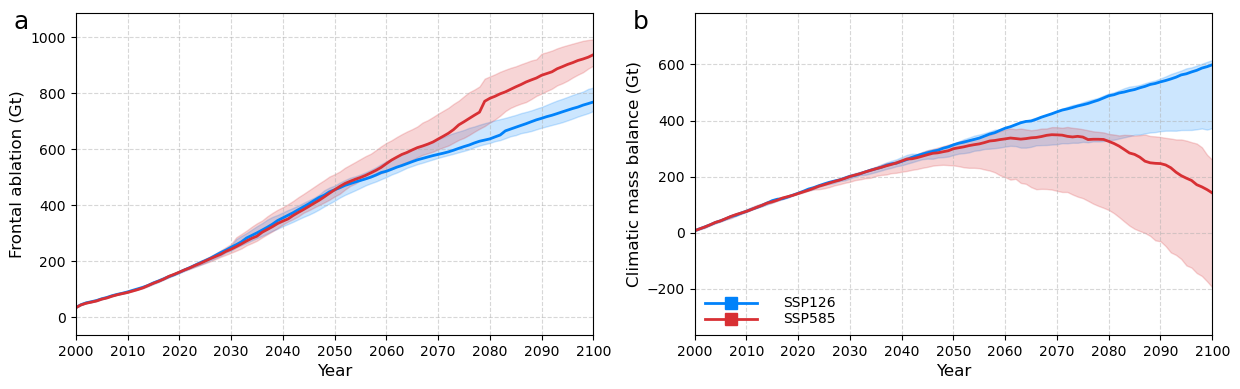

In [97]:
plot_three_cumulative_statistics_subplots_horizontal(
    FA_stats= FA_cumulative_stats_summary_total,
    MBclim_stats= MBclim_cumulative_stats_summary_total,
    MBtotal_stats= MBtotal_cumulative_stats_summary_total,
    output_path=postpro_figure_fp_region,
    file_suffix="regional_analysis_horizontal"
)

Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Simulation/figures/07/Cumulative_Statistics_SamePhysicalScale_regional_analysis_horizontal_converged_Total_Updated.png


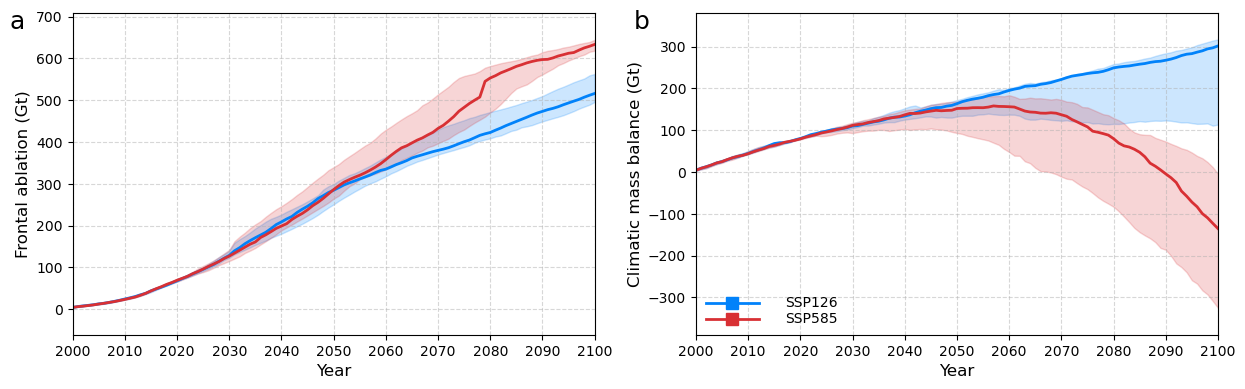

In [162]:
plot_three_cumulative_statistics_subplots_horizontal(
    FA_stats= FA_cumulative_stats_summary_converged,
    MBclim_stats= MBclim_cumulative_stats_summary_converged,
    MBtotal_stats= MBtotal_cumulative_stats_summary_converged,
    output_path=postpro_figure_fp_region,
    file_suffix="regional_analysis_horizontal_converged"
)

In [141]:
(FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2050]-FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2000])/50

8.400023294102732

In [138]:
(FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2100]-FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2050])/50

6.268612605451233

In [139]:
(FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2100]-FA_cumulative_stats_summary_total['ssp126']['Median'].loc[2080])/20

6.584214246018513

In [142]:
(FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2000])/100

9.028360097314648

In [143]:
(FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2050]-FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2000])/50

8.413378405600886

In [144]:
(FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2050])/50

9.643341789028412

In [147]:
(FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-FA_cumulative_stats_summary_total['ssp585']['Median'].loc[2080])/20

7.775665033179058

In [148]:
(MBclim_cumulative_stats_summary_total['ssp126']['Median'].loc[2100]-MBclim_cumulative_stats_summary_total['ssp126']['Median'].loc[2000])/100

5.920619013289557

In [149]:
(MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2000])/100

1.3483862293999525

In [153]:
(MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2050]-MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2000])/50

5.8499080523701705

In [151]:
(MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2050])/50

-3.1531355935702656

In [152]:
(MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2100]-MBclim_cumulative_stats_summary_total['ssp585']['Median'].loc[2080])/20

-9.200882752597908

In [154]:
FA_cumulative_stats_summary_converged

{'ssp126':           Median          Q1          Q3 Included_GCM_Count
 2000    4.506081    4.239002    5.218942                 12
 2001    6.474819    5.655871     7.43624                 12
 2002    8.055451    7.161917    9.339673                 12
 2003    9.426602    8.572348   10.714595                 12
 2004   10.901231   10.313202   12.356642                 12
 ...          ...         ...         ...                ...
 2096  497.833405  474.088555   543.11938                 12
 2097   501.97971  479.874051  547.641911                 12
 2098   507.20889  484.716654  551.992375                 12
 2099  511.852471  489.276353  559.415027                 12
 2100   516.19396  495.793747  562.857492                 12
 
 [101 rows x 4 columns],
 'ssp585':           Median          Q1          Q3 Included_GCM_Count
 2000    4.427588    4.159103    4.699107                 12
 2001    6.241492     5.95869    6.461157                 12
 2002    7.476821    7.185843    7.944

### statistic of converged in the total 

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional, Union

def calculate_converged_percentage(
    total_fa: Dict[str, pd.DataFrame], 
    converged_fa: Dict[str, pd.DataFrame],
    return_dataframes: bool = False,
    plot_results: bool = True,
    include_uncertainty: bool = True
) -> Union[Dict, pd.DataFrame]:
    """
    Calculate the mean percentage of converged FA relative to total FA over 2000-2100.
    
    Parameters:
    -----------
    total_fa : dict
        Dictionary with scenario names as keys and DataFrames containing total FA data.
        Each DataFrame should have columns: 'Median', 'Q1', 'Q3'
    converged_fa : dict
        Dictionary with scenario names as keys and DataFrames containing converged FA data.
        Each DataFrame should have columns: 'Median', 'Q1', 'Q3'
    return_dataframes : bool, default=False
        If True, returns DataFrames with annual percentages for each scenario
    plot_results : bool, default=True
        If True, creates a plot showing percentage trends over time
    include_uncertainty : bool, default=True
        If True, includes Q1/Q3 uncertainty in calculations and plot
    
    Returns:
    --------
    dict or pd.DataFrame
        If return_dataframes=False: Dictionary with summary statistics for each scenario
        If return_dataframes=True: DataFrame with annual percentages for each scenario
    """
    
    # Validate inputs
    if not total_fa.keys() == converged_fa.keys():
        raise ValueError("Total FA and Converged FA must have the same scenarios")
    
    results = {}
    percentage_dfs = []
    
    for scenario in total_fa.keys():
        # Extract data
        total_df = total_fa[scenario]
        converged_df = converged_fa[scenario]
        
        # Ensure we're working with numeric values
        total_median = pd.to_numeric(total_df['Median'], errors='coerce')
        converged_median = pd.to_numeric(converged_df['Median'], errors='coerce')
        
        # Calculate percentages (handle potential division by zero)
        with np.errstate(divide='ignore', invalid='ignore'):
            percentage = (converged_median / total_median * 100)
        
        # Store annual data if requested
        if return_dataframes:
            percentage_dfs.append(percentage.rename(scenario))
        
        # Get year values as numeric array for trend calculation
        years = np.array(percentage.index, dtype=float)
        values = percentage.values.astype(float)
        
        # Remove any NaN or infinite values for trend calculation
        valid_mask = np.isfinite(values)
        if valid_mask.sum() > 1:  # Need at least 2 points for trend
            trend_slope = np.polyfit(years[valid_mask], values[valid_mask], 1)[0]
        else:
            trend_slope = None
        
        # Calculate statistics
        stats = {
            'scenario': scenario,
            'mean_percentage': percentage.mean(),
            'min_percentage': percentage.min(),
            'max_percentage': percentage.max(),
            'std_percentage': percentage.std(),
            'first_year_2000': percentage.loc[2000] if 2000 in percentage.index else None,
            'last_year_2100': percentage.loc[2100] if 2100 in percentage.index else None,
            'trend_slope': trend_slope
        }
        
        # Add uncertainty if requested
        if include_uncertainty:
            # Convert Q1/Q3 to numeric
            total_q3 = pd.to_numeric(total_df['Q3'], errors='coerce')
            total_q1 = pd.to_numeric(total_df['Q1'], errors='coerce')
            converged_q1 = pd.to_numeric(converged_df['Q1'], errors='coerce')
            converged_q3 = pd.to_numeric(converged_df['Q3'], errors='coerce')
            
            # Calculate uncertainty bounds (simplified approach)
            with np.errstate(divide='ignore', invalid='ignore'):
                q1_percentage = (converged_q1 / total_q3 * 100)
                q3_percentage = (converged_q3 / total_q1 * 100)
            
            stats.update({
                'mean_q1_bound': q1_percentage.mean(),
                'mean_q3_bound': q3_percentage.mean(),
                'uncertainty_range': (q3_percentage - q1_percentage).mean()
            })
        
        results[scenario] = stats
        
        # Print summary
        print(f"\n{'='*50}")
        print(f"Scenario: {scenario}")
        print(f"{'='*50}")
        print(f"Mean percentage: {stats['mean_percentage']:.2f}%")
        print(f"Min percentage: {stats['min_percentage']:.2f}%")
        print(f"Max percentage: {stats['max_percentage']:.2f}%")
        print(f"Std deviation: {stats['std_percentage']:.2f}%")
        
        if stats['first_year_2000'] is not None:
            print(f"2000 value: {stats['first_year_2000']:.2f}%")
        if stats['last_year_2100'] is not None:
            print(f"2100 value: {stats['last_year_2100']:.2f}%")
        
        if stats['trend_slope'] is not None:
            print(f"Trend slope: {stats['trend_slope']:.3f}%/year")
        
        if include_uncertainty and 'uncertainty_range' in stats:
            print(f"Mean uncertainty range: ±{stats['uncertainty_range']/2:.2f}%")
    
    # Create combined DataFrame if requested
    if return_dataframes and percentage_dfs:
        result_df = pd.concat(percentage_dfs, axis=1)
        if plot_results:
            plot_percentage_trends(result_df, include_uncertainty, total_fa, converged_fa)
        return result_df
    
    # Plot if requested but not returning DataFrames
    if plot_results:
        plot_percentage_trends_from_stats(total_fa, converged_fa, include_uncertainty)
    
    return results


def plot_percentage_trends(
    percentage_df: pd.DataFrame, 
    include_uncertainty: bool,
    total_fa: Optional[Dict] = None,
    converged_fa: Optional[Dict] = None
) -> None:
    """Helper function to plot percentage trends"""
    plt.figure(figsize=(12, 8))
    
    for scenario in percentage_df.columns:
        # Ensure data is numeric and finite
        values = pd.to_numeric(percentage_df[scenario], errors='coerce')
        plt.plot(percentage_df.index, values, 
                label=scenario, linewidth=2)
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title('Converged FA as Percentage of Total FA (2000-2100)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add uncertainty shading if requested and data available
    if include_uncertainty and total_fa is not None and converged_fa is not None:
        for scenario in percentage_df.columns:
            # Convert to numeric
            total_q3 = pd.to_numeric(total_fa[scenario]['Q3'], errors='coerce')
            total_q1 = pd.to_numeric(total_fa[scenario]['Q1'], errors='coerce')
            converged_q1 = pd.to_numeric(converged_fa[scenario]['Q1'], errors='coerce')
            converged_q3 = pd.to_numeric(converged_fa[scenario]['Q3'], errors='coerce')
            
            with np.errstate(divide='ignore', invalid='ignore'):
                q1_pct = (converged_q1 / total_q3 * 100)
                q3_pct = (converged_q3 / total_q1 * 100)
            
            # Fill only finite values
            plt.fill_between(percentage_df.index, 
                            np.where(np.isfinite(q1_pct), q1_pct, np.nan),
                            np.where(np.isfinite(q3_pct), q3_pct, np.nan), 
                            alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def plot_percentage_trends_from_stats(
    total_fa: Dict,
    converged_fa: Dict,
    include_uncertainty: bool
) -> None:
    """Helper function to plot when not returning DataFrames"""
    plt.figure(figsize=(12, 8))
    
    for scenario in total_fa.keys():
        # Convert to numeric
        total_median = pd.to_numeric(total_fa[scenario]['Median'], errors='coerce')
        converged_median = pd.to_numeric(converged_fa[scenario]['Median'], errors='coerce')
        
        with np.errstate(divide='ignore', invalid='ignore'):
            percentage = (converged_median / total_median * 100)
        
        # Plot only finite values
        years = percentage.index
        values = percentage.values
        valid_mask = np.isfinite(values)
        
        if valid_mask.any():
            plt.plot(years[valid_mask], values[valid_mask], 
                    label=scenario, linewidth=2)
        
        if include_uncertainty:
            # Convert to numeric
            total_q3 = pd.to_numeric(total_fa[scenario]['Q3'], errors='coerce')
            total_q1 = pd.to_numeric(total_fa[scenario]['Q1'], errors='coerce')
            converged_q1 = pd.to_numeric(converged_fa[scenario]['Q1'], errors='coerce')
            converged_q3 = pd.to_numeric(converged_fa[scenario]['Q3'], errors='coerce')
            
            with np.errstate(divide='ignore', invalid='ignore'):
                q1_pct = (converged_q1 / total_q3 * 100)
                q3_pct = (converged_q3 / total_q1 * 100)
            
            # Fill only where both bounds are finite
            valid_uncertainty = np.isfinite(q1_pct) & np.isfinite(q3_pct)
            if valid_uncertainty.any():
                plt.fill_between(years[valid_uncertainty], 
                               q1_pct[valid_uncertainty], 
                               q3_pct[valid_uncertainty], 
                               alpha=0.2)
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title('Converged FA as Percentage of Total FA (2000-2100)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()



Scenario: ssp126
Mean percentage: 54.70%
Min percentage: 13.26%
Max percentage: 67.26%
Std deviation: 15.61%
2000 value: 13.26%
2100 value: 67.26%
Trend slope: 0.465%/year
Mean uncertainty range: ±6.99%

Scenario: ssp585
Mean percentage: 55.72%
Min percentage: 13.32%
Max percentage: 70.98%
Std deviation: 16.42%
2000 value: 13.32%
2100 value: 67.68%
Trend slope: 0.501%/year
Mean uncertainty range: ±9.66%

Scenario: ssp126
Mean percentage: 54.70%
Min percentage: 13.26%
Max percentage: 67.26%
Std deviation: 15.61%
2000 value: 13.26%
2100 value: 67.26%
Trend slope: 0.465%/year
Mean uncertainty range: ±6.99%

Scenario: ssp585
Mean percentage: 55.72%
Min percentage: 13.32%
Max percentage: 70.98%
Std deviation: 16.42%
2000 value: 13.32%
2100 value: 67.68%
Trend slope: 0.501%/year
Mean uncertainty range: ±9.66%


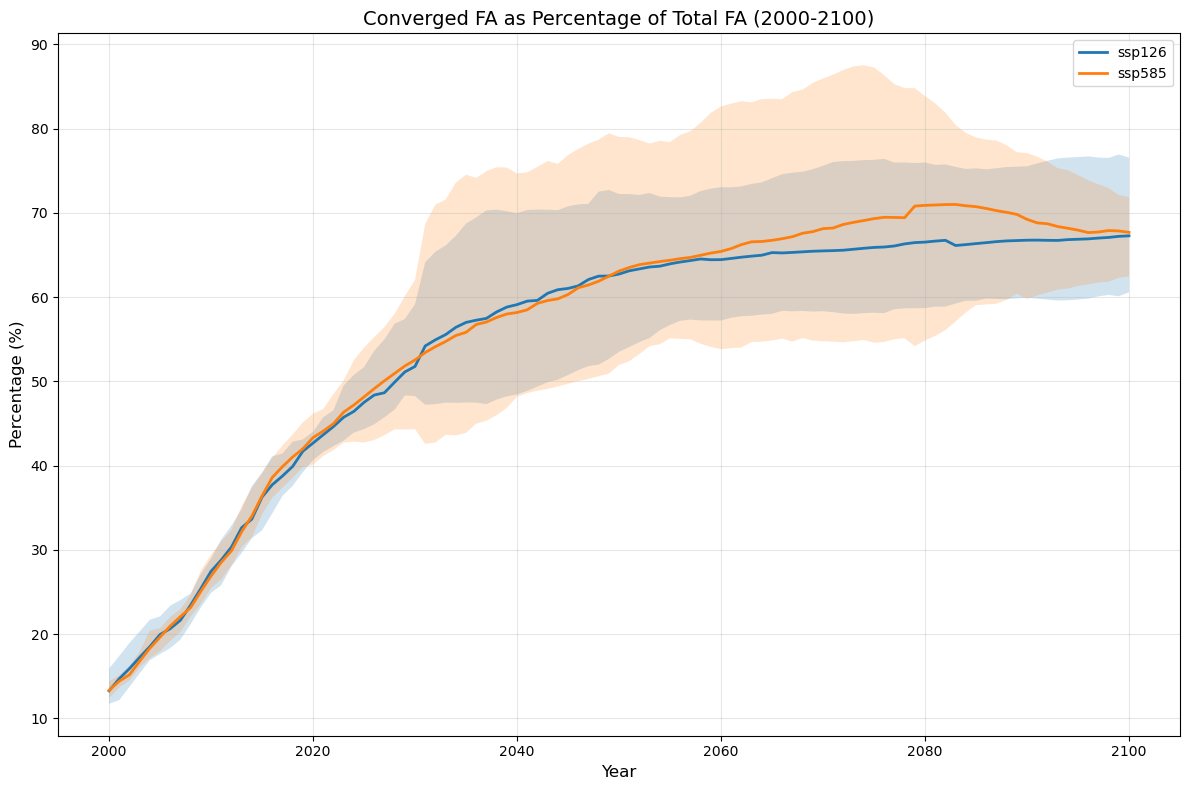

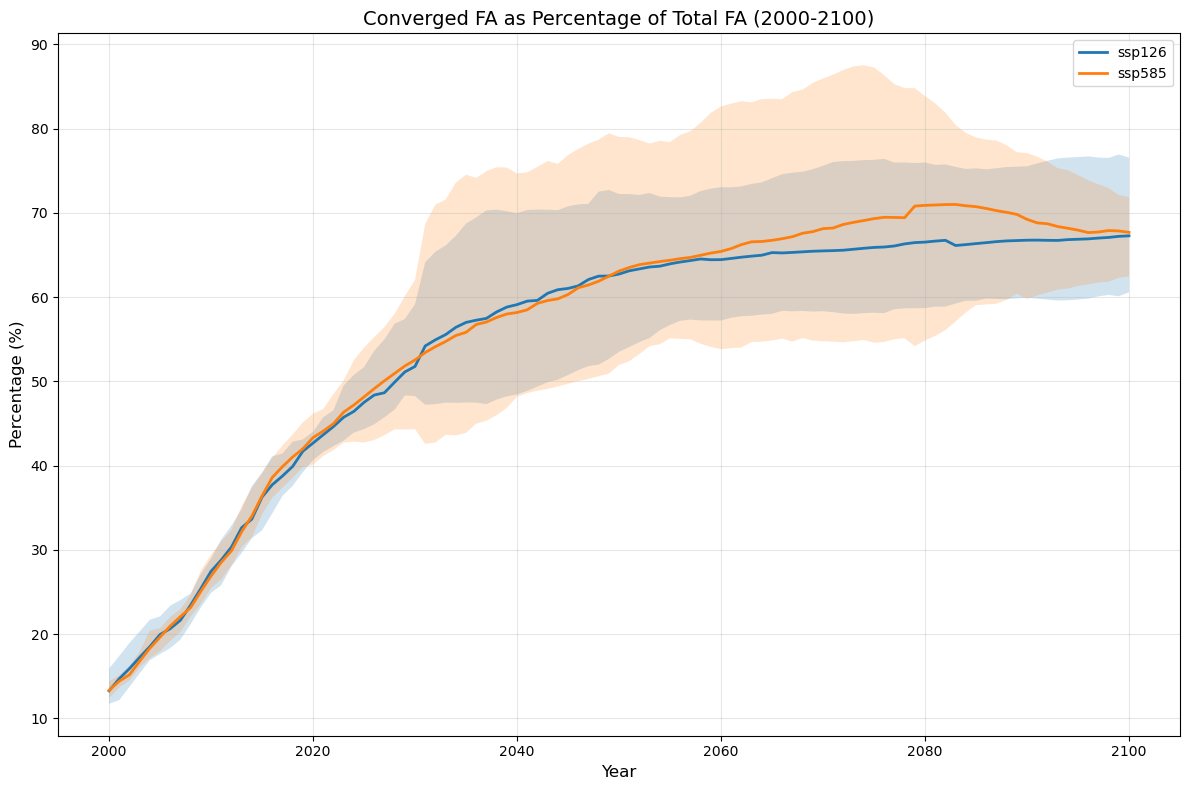

In [160]:
# Get summary statistics
results = calculate_converged_percentage(FA_cumulative_stats_summary_total, FA_cumulative_stats_summary_converged)

# Get annual percentages DataFrame for further analysis
percentage_df = calculate_converged_percentage(
    FA_cumulative_stats_summary_total, 
    FA_cumulative_stats_summary_converged, 
    return_dataframes=True,
    plot_results=True
)


Scenario: ssp126
Mean percentage: 53.68%
Min percentage: 49.66%
Max percentage: 64.08%
Std deviation: 3.31%
2000 value: 60.80%
2100 value: 50.33%
Trend slope: -0.105%/year
Mean uncertainty range: ±15.14%

Scenario: ssp585
Mean percentage: 36.99%
Min percentage: -95.58%
Max percentage: 64.05%
Std deviation: 32.00%
2000 value: 56.78%
2100 value: -95.58%
Trend slope: -0.852%/year
Mean uncertainty range: ±-3.24%

Scenario: ssp126
Mean percentage: 53.68%
Min percentage: 49.66%
Max percentage: 64.08%
Std deviation: 3.31%
2000 value: 60.80%
2100 value: 50.33%
Trend slope: -0.105%/year
Mean uncertainty range: ±15.14%

Scenario: ssp585
Mean percentage: 36.99%
Min percentage: -95.58%
Max percentage: 64.05%
Std deviation: 32.00%
2000 value: 56.78%
2100 value: -95.58%
Trend slope: -0.852%/year
Mean uncertainty range: ±-3.24%


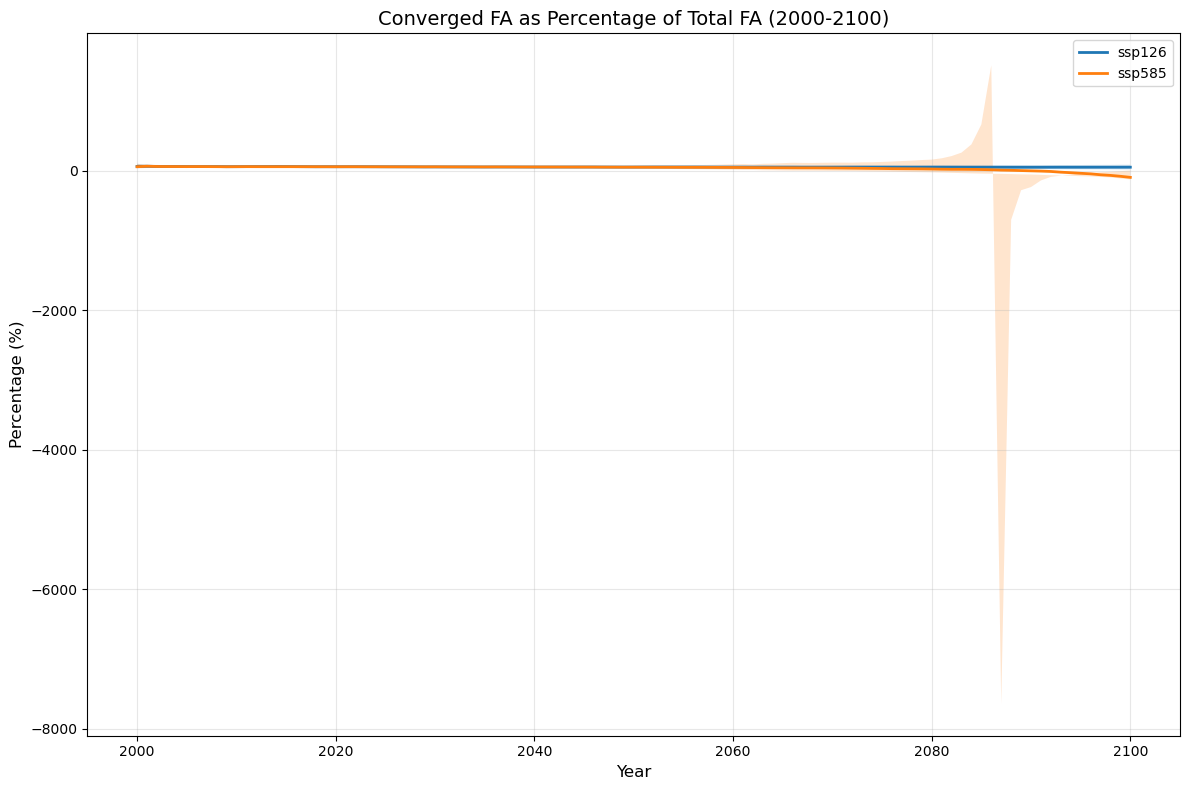

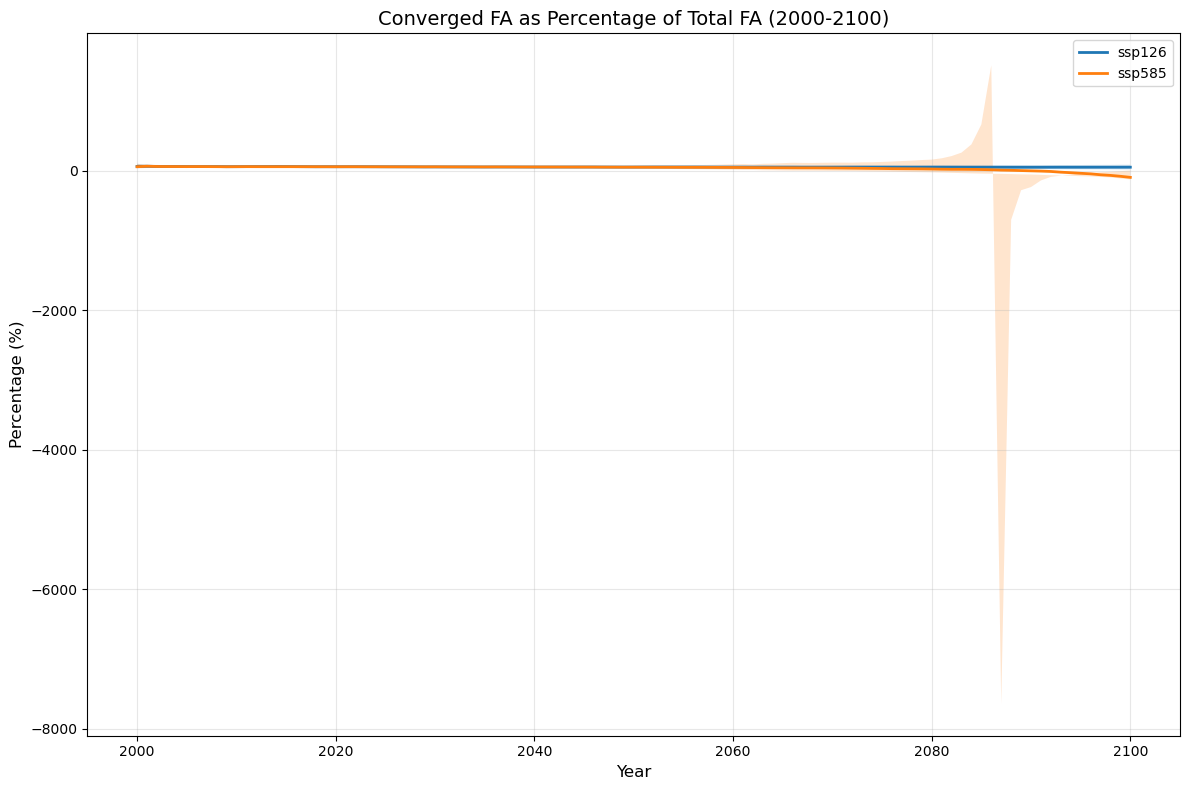

In [161]:
# Get summary statistics
results = calculate_converged_percentage(MBclim_cumulative_stats_summary_total, MBclim_cumulative_stats_summary_converged)

# Get annual percentages DataFrame for further analysis
percentage_df = calculate_converged_percentage(
    MBclim_cumulative_stats_summary_total, 
    MBclim_cumulative_stats_summary_converged, 
    return_dataframes=True,
    plot_results=True
)